# A place to toy around with spaceprime stuff
Notes are in my Obsidian vault. 
Note to self- I'm using the spaceprime conda environment.

## Function to convert raster stack to K values

I'm writing a function to convert a single raster or multiple rasters to local carrying capacities (K) with the possibility of a linear, hinge, or sigmoid transformation

This is a basic function to transform a raster to local carrying capacity (K) values. This function was created with the idea of taking in presence probability/habitat suitability rasters scaled from 0 to 1, where 0 is no suitability and 1 is the highest suitability. However, it is flexible enough to accomodate other continuous rasters that can be coaxed to a 0 to 1 scale with the operation `(data - np.min(data)) / (np.max(data) - np.min(data))` by setting the `normalize` flag to `True`. 
- The "linear" transformation multiplies the input (raw or transformed) values by the maximum local carrying capacity (max_local_k).
- The "hinge" transformation creates a raster where values below the `threshold` value are set to zero and values about the `threshold` value are set to 1. Note, this transformation is applied *after* normalizing if the `normalize` flag is set to `True`.
- The "sigmoid" transformation applies a sigmoid function to the data using Eq. 1 from [Frazier and Wang 2013, Modeling landscape structure response across a gradient of land cover intensity](https://www.researchgate.net/publication/257319938_Modeling_landscape_structure_response_across_a_gradient_of_land_cover_intensity), where an `inflection_point` and `slope` are specified. The `inflection_point` can be thought of like a `threshold` value, where original values below this value descend quicker to zero, and values about this value increase quicker to 1. The slope determines how fast values change on either side of the inflection point. A sufficiently steep slope makes this a hinge function, while a sufficiently shallow slope makes this a linear function.

In [1]:
import numpy as np
def raster_to_k(raster, transformation = "linear", max_local_k = 100, normalize = False, threshold = None, inflection_point = 0.5, slope = 0.05):

    d = raster.filled(0)

    if normalize:
        def normalize(rast):
            return (rast - np.min(rast)) / (np.max(rast) - np.min(rast))
        
        d = normalize(d)
    
    if transformation == "linear":
        t = d * max_local_k
        t = np.ceil(t)

    if transformation == "hinge":
        t = d
        t[t >= threshold] = max_local_k
        t[t < threshold] = 1e-10

    if transformation == "sigmoid":
        def sigmoid(x, a, b):
            y = 1.0 / (1.0 + np.ma.exp(-(x - a) / b))
            return(y)
        
        sigmoid_v = np.vectorize(sigmoid)
        t = sigmoid_v(d, inflection_point, slope) * max_local_k
        t = np.ceil(t)
    
    t[t == 0] = 1e-10
    
    return(t)
    
  

## Migration matrix from deme sizes
This is a skeleton to facilitate creating a migration matrix from a matrix of deme sizes.  
The formula for scaling the migration rates, which is always recommended is:  
mig donor -> recipient = (donor size / recipient size) * rate  
(we're thinking backward in time)  

In `migration_matrix()`, migration can occur in four directions from the focal deme unless they are at the edge of the matrix. In `migration_matrix_diagonal()`, diagonal migration is also allowed. I'm not sure if I want to allow diagonal in the final implementation, but keeping it here for posterity.

In [2]:
import numpy as np

def migration_matrix(populations, rate, scale=True):
    d = populations.shape[0] * populations.shape[1]
    M = np.zeros((d, d))
    
    for i in range(populations.shape[0]):
        for j in range(populations.shape[1]):
            current_index = i * populations.shape[1] + j
            # check the neighboring populations and calculate the migration rates. Looping through tuples was a neat trick! Saved a lot of time.
            for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                # check for edges
                if 0 <= i + di < populations.shape[0] and 0 <= j + dj < populations.shape[1]:
                    neighbor_index = (i + di) * populations.shape[1] + (j + dj)
                    if scale:
                        # mig = donor / recipient * rate unless the pop size is zero
                        M[current_index, neighbor_index] = (populations[i + di, j + dj] / populations[i, j]) * rate if populations[i + di, j + dj] > 1e-9 and populations[i, j] > 1e-9 else 0
                    else:
                        M[current_index, neighbor_index] = rate if populations[i + di, j + dj] > 1e-9 and populations[i, j] > 1e-9 else 0


    return M


## 2D Stepping Stone model

Now to write a basic function! This will read in a single raster and create an msprime demography object with that single raster. I updated the function to use the `migration_matrix()` function, which is faster than the original implementation.  
`deme_size_matrix` is the local population size for each deme in the model  
`rate` is the migration rate between populations. Can be a single numerical value or a matrix that corresponds to all migration edges in the model.  
`scale` is a logical, determining if the migration rates should be scaled by the donor and recipient population sizes (True) or not. True is the default, since this is recommended behavior.


In [3]:
import msprime
import numpy as np

def stepping_stone2d(deme_size_matrix, rate, scale=True):
    assert len(deme_size_matrix.shape) <= 3

    n, m = deme_size_matrix.shape
    N = n * m
    model = msprime.Demography.isolated_model(deme_size_matrix.reshape(N))

    # set population names
    for j in range(n):
        for k in range(m):
            index = j * m + k
            model.populations[index].name = f"pop_{j}_{k}"
    
    # setup migration rate matrices
    if np.array(rate).ndim == 0:
        if scale:
            model.migration_matrix = migration_matrix(deme_size_matrix, rate, scale=True)
        else: 
            model.migration_matrix = migration_matrix(deme_size_matrix, rate, scale=False)
    else:
        assert rate.shape == (N, N), f"Expected a migration matrix with the shape {(N, N)} and instead got {rate.shape}"
        model.migration_matrix = rate

    
    return model

## Demographic changes based on landscape change to 2D stepping stone model

The `model` is an `msprime.Demography` object that needs to be initialized using `stepping_stone_2d()`.  
`k_stack` is a 3D numpy array of the local carrying capacities across the landscape for each timestep except the most current timestep.  
`timestep` is the amount of time that passes between each landscape change, measured in generations. For instance, if each landscape is 100 years apart and the generation time of the organism is 1 year, `timestep` is 100. However, if the generation time of the organism is 2 years, `timestep` is 50. 


In [4]:
import msprime
import numpy as np
def add_landscape_change(model, k_stack, timestep = 1, rate = 0.001, scale=True):
    # iterate through the first dimension of a 3D array, where the array represents different time steps of population size change
    # omit the most ancient time step (have to set its migration rate differently)
    for step in range(1, k_stack.shape[0] - 1):
        # get the population size values of the current array
        kmat = k_stack[step]

        # get the population size values of array from the more ancient time step
        kmat_anc = k_stack[step + 1]

        # get the population size values array from the more recent time step
        kmat_prev = k_stack[step - 1]

        # get the shape of the array
        n, m = kmat.shape

        ##### Update population sizes #####
        # add population size changes according to the values of the current array
        for j in range(n):
            for k in range(m):
                # only update the population size if it is different from the previous time point
                if kmat[j, k] != kmat_prev[j, k]:
                    # add a demographic change to each cell in the raster
                    model.add_population_parameters_change(time=step * timestep, population=f"pop_{j}_{k}", initial_size=kmat[j, k])

        ##### Update migration rates #####
        # add migration rate change for each time step
        # this is updating time steps from the present to the past
        # ## iterate through the population sizes
        for i in range(n):
            for j in range(m):
                ## also index the neighboring cells
                for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    ## check for edges
                    if 0 <= i + di < kmat.shape[0] and 0 <= j + dj < kmat.shape[1]:
                        ## only update migration if the donor and recipient population sizes are different between time points
                        if kmat_prev[i + di, j + dj] != kmat[i + di, j + dj] and kmat[i, j] != kmat_prev[i, j]:
                            if scale:
                                ## mig = donor / recipient * rate unless the pop size is zero
                                r = (kmat[i + di, j + dj]  / kmat[i, j]) * rate if kmat[i + di, j + dj] > 1e-9 and kmat[i, j] > 1e-9 else 0
                                model.add_migration_rate_change(time = step * timestep, rate = r, source=f"pop_{i}_{j}", dest=f"pop_{i + di}_{j + dj}")
                            else:
                                model.add_migration_rate_change(time = step * timestep, rate = rate, source=f"pop_{i}_{j}", dest=f"pop_{i + di}_{j + dj}")
                        elif kmat_prev[i + di, j + dj] != kmat[i + di, j + dj] and kmat[i, j] != kmat_prev[i, j] and kmat_anc[i, j] <= 1e-9:
                            ## have the deme migrate to neighbors if the more ancient time step has an empty deme
                            model.add_migration_rate_change(time = step * timestep, rate = 1.0, source=f"pop_{i}_{j}", dest=f"pop_{i + di}_{j + dj}")
    
    return model


## Add nonspatial phase to 2D stepping stone model
Functions:  
`split_landscape_by_admix_pop()`  
`add_nonspatial_phase()`

`split_landscape_by_admix_pop()`  
Function to split a landscape according to the "STRUCTURE" population assigned to sampled individuals (often denoted with K and considered an admixture population)  
`raster_path` is the path to the landscape raster (i.e. SDM projection) that you want to divide.  
`coords` is a list of tuples of the coordinates assigned to each individual in the empirical data set  
`admix_id` is the population ID assigned to each individual in the empirical dataset. For example, if STRUCTURE finds a "best K" of two, every individual in the data set is assigned to one of two populations. There should be one ID for every coordinate pair.  
`outfile` is the path to where you want to write the new raster, including the ".tif" extension to write a GeoTIFF. Right now I'm just supporting the GeoTIFF format to keep things simple.   
`band_index` is the index of the raster you want to read in, in case your raster contains multiple bands. The default is one (note- rasterio begins indexing at 1 for raster bands)   
`mask_rast` is a boolean of whether you want to mask the interpolation by the SDM landscape or let it fill the entire extent. For the purposes of parameterizing the 2DSS, you want it to fill the entire extent, but it is useful to visualize it on the landscape.   


In [5]:
from scipy.interpolate import NearestNDInterpolator
import numpy as np
from numpy import ma
from os.path import splitext
from shapely.geometry import Point
import rasterio
from rasterio.mask import mask


# function to split a landscape according to the "STRUCTURE" population assigned to sampled individuals (these populations can be considered admixture populations)
# raster_path is the path to the landscape raster (i.e. SDM projection) that you want to divide. 
# coords is a list of tuples of the coordinates assigned to each individual in the empirical data set
# admix_id is the population ID assigned to each individual in the empirical dataset. For example, if STRUCTURE finds a "best K" of two, every individual in the data set is assigned to one of two populations. There should be one ID for every coordinate pair.
# outfile is the path to where you want to write the new raster, including the ".tif" extension to write a GeoTIFF. Right now I'm just supporting the GeoTIFF format to keep things simple. 
# band_index is the index of the raster you want to read in, in case your raster contains multiple bands. The default is one (note- rasterio begins indexing at 1 for raster bands)
# mask_rast is a boolean of whether you want to mask the interpolation by the SDM landscape or let it fill the entire extent. For the purposes of parameterizing the 2DSS, you want it to fill the entire extent, but it is useful to visualize it on the landscape. 
def split_landscape_by_admix_pop(raster_path, coords, admix_id, outfile, band_index=1, mask_rast=False):

    # open the raster
    r = rasterio.open(raster_path)
    # read in the raster. This imports the raster as a numpy array
    r2 = r.read(band_index, masked=True)

    # get the x,y indices of the empirical sampled cells
    indices_x = []
    indices_y = []
    for xy in coords:
    
        # mask requires an iterable as input, so I just repeated the two Point geometries in a list. Mask returns a single value since they overlap in the same place
        pt2 = [Point(xy), Point(xy)]
        
        # mask the raster with the points
        out_image = mask(r, pt2, nodata="nan", filled = False)

        # oi first raster
        oi = out_image[0][0]

        # get the locality index
        indices_tup = ma.nonzero(oi)

        indices_x.append(indices_tup[0])
        indices_y.append(indices_tup[1])

    indices_x = np.concatenate(indices_x)
    indices_y = np.concatenate(indices_y)

    # get all of the x, y indices of the input raster
    r_x, r_y = np.indices(r.shape)

    interp = NearestNDInterpolator(list(zip(indices_x, indices_y)), admix_id)
    z = interp(r_x, r_y)

    # apply mask of the SDM landscape
    if mask_rast:
         z = ma.masked_array(z, r2.mask, fill_value=-9, dtype=float)

    # check to make sure the filepath contains the ".tif" suffix, then write the file out
    try: 
        root, ext = splitext(outfile)
        if ext != ".tif" or "~" in root:
            raise SyntaxError
        print(f"Landscape with K assignment categories written to {outfile}.")
    except SyntaxError:
        print("The outfile cannot use tilde (~) path expansion and must have a .tif extension.")

    
    with rasterio.open(
            outfile,
            mode="w",
            driver="GTiff",
            height=z.shape[0],
            width=z.shape[1],
            count=1,
            dtype=z.dtype,  
            crs=r.crs,
            transform=r.transform,
            nodata=-9
        ) as new_dataset:
            new_dataset.write(z, 1)
    


`add_nonspatial_phase()`- add the nonspatial phase to the 2D stepping stone model, either including a single ancestral population or multiple ancestral populations.

`ancestral_size_list` is a list of ancestral population sizes that correspond with each admixture population, unless there is a single ancestral population.

`merge_time` is the time in generations that the metapopulation merges into the ancestral population(s)

`admix_id_rast` is the raster that contains which admixture populations (defined in a "STRUCTURE" type analysis) each deme belongs to. This can be created with `split_landscape_by_admix_pop()`. It is read in in "read" mode.

`ancestral_merge_time_list` is a list of times when the ancestral populations merge with each other. It should be either of size N - 1, where N is the number of ancestral populations, or 1, where all ancestral populations merge at the same time in the past. If it is left blank, it is assumed that the ancestral populations do not merge with each other. The assumed branching pattern is from left to right (e.g. for three ancestral populations, the pattern is ((ANC_1, ANC_2), ANC_3)). Make sure the `admix_id` associated with 

`ancestral_merge_size_list` is a list of the sizes of the new ancestral populations after the merge. It should be the same size as the `ancestral_merge_time_list`

In [6]:

# admix_id_rast is the raster that contains which admixture populations (defined in a "STRUCTURE" type analysis) each deme belongs to. It assumes that the populations are numbered sequentially, starting at 1. 
# ancestral_size_list is a list of ancestral population sizes that correspond with each admixture population ID
# ancestral_merge_time_list is a list of times when the ancestral populations merge with each other. It should be either of size N - 1, where N is the number of ancestral populations, or 1, where all ancestral populations merge at the same time in the past. The assumed branching pattern is from left to right (e.g. for three ancestral populations, the pattern is ((ANC_1, ANC_2), ANC_3))
# ancestral_merge_size_list is a list of the sizes of the new ancestral populations after the merge. It should be the same size as the ancestral_merge_time_list
def add_nonspatial_phase(model, ancestral_size_list, merge_time, admix_id_rast=None, ancestral_merge_time_list=None, ancestral_merge_size_list=None):

    if admix_id_rast is None:
        # add an ancestral population
        model.add_population(name = "ANC", initial_size=ancestral_size_list[0])

        # get names of populations for initiating the merge
        pop_names = [[pop.name] for pop in model.populations if "ANC" not in pop.name]
        
        # add the time when the spatial simulation collapses into the collecting phase
        [model.add_population_split(time = merge_time, derived = name, ancestral = "ANC") for name in pop_names]
    else:

        # make sure the admixture ID raster has the same number of populations as the raster used in the demographic modeling
        try:
            admix_id_1d = admix_id_rast.ravel()
            if len(model.populations) != len(admix_id_1d):
                raise ValueError
        except ValueError:
            print(f"The number of demes in the demographic model is {len(model.populations)}, while the number of demes in the admixture ID raster is {len(admix_id_1d)}. They need to be the same.")

        
        # add a new ancestral population for each admixture population
        for i in range(1, len(ancestral_size_list) + 1):
            anc_pop_name = f"ANC_{i}"
            model.add_population(name = anc_pop_name, initial_size=ancestral_size_list[i - 1])

        # merge each deme in the simulation into its respective ancestral population
        for i in range(len(model.populations)):
            pop_name = model.populations[i].name
            if "ANC" not in pop_name:
                anc_pop = f"ANC_{admix_id_1d[i]}"
                model.add_population_split(time = merge_time, derived = [pop_name], ancestral = anc_pop)

        # merge ancestral populations at their respective times, if we want that behavior
        if ancestral_merge_time_list is not None:
            try:
                if len(ancestral_merge_time_list) != len(ancestral_size_list) + 1 and len(ancestral_merge_time_list) != 1:
                    raise ValueError
            except ValueError:
                print("The ancestral merge list should be of length N - 1 or 1")
            
            # make sure the ancestral merge list is either of size 1 or N - 1
            if len(ancestral_size_list) > 1 and len(ancestral_merge_time_list) > 1:
                for i in range(1, len(ancestral_size_list)):
                    if i == 1:
                        n1 = f"ANC_{i}"
                        n2 = f"ANC_{i + 1}"
                        anc_n = f"ANC_{i}_{i + 1}"
                    else:
                        anc_num_str = "_".join(map(str, range(1, i + 1)))
                        n1 = f"ANC_{anc_num_str}"
                        n2 = f"ANC_{i + 1}"
                        anc_n = f"ANC_{anc_num_str}_{i + 1}"
                    ## add the new ancestral populations to the simulation
                    model.add_population(name = anc_n, initial_size=ancestral_merge_size_list[i - 1])
                    model.add_population_split(time = ancestral_merge_time_list[i - 1], derived = [n1, n2], ancestral = anc_n)
            ## if there are multiple ancestral populations, but a single merge time
            elif len(ancestral_size_list) > 1 and len(ancestral_merge_time_list) == 1:
                # get a list of the ancestral population names
                anc_der_pops = []
                for i in range(1, len(ancestral_size_list) + 1):
                    anc_der_name = f"ANC_{i}"
                    anc_der_pops.append(anc_der_name)
                # make the name of the most ancestral population
                anc_num_str = "_".join(map(str, range(1, len(ancestral_size_list) + 1)))
                anc_n = f"ANC_{anc_num_str}"
                ## add the new ancestral populations to the simulation
                model.add_population(name = anc_n, initial_size=ancestral_merge_size_list[0])
                model.add_population_split(time = ancestral_merge_time_list[0], derived = anc_der_pops, ancestral = anc_n)


    return model

## Determine which populations to sample

`coords_to_sample_dict()` takes the raster you used for setting up your demographic model and lat-long sampling coordinates and returns a dictionary used for specifying the populations and number of samples per population you want for your simulations. 

In [7]:
import rasterio
from rasterio.mask import mask
import numpy as np
from numpy import ma

# raster is a raster opened in rasterio in "r" mode and is the same raster used to parameterize the demographic model
# coordinates is a list of longitude-latitude coordinate tuples. Note- make sure the raster and coordinates are in the same projection.
# num_inds is either a single number or a vector of numbers that correspond with the number of individuals (not genomes) you want to sample per population

def coords_to_sample_dict(raster, coordinates, num_inds):

    coords_shape = [Point(xy) for xy in coordinates]
    # mask the raster, so only cells that the coordinates overlap are masked
    out_image = mask(raster, coords_shape, nodata="nan", filled = False)

    # unravel the masked raster into a single dimension, only keeping the first raster in case there are multiple rasters in the dataset
    oi_1d = out_image[0][0].ravel()

    # get the indices of the localities
    cell_id = ma.nonzero(oi_1d)[0]
    

    if isinstance(num_inds, int):

        # function to split list into even-sized chunks from a list
        # stolen from https://stackoverflow.com/a/312464/4406870
        def chunks(lst, n):
            """Yield successive n-sized chunks from lst."""
            for i in range(0, len(lst), n):
                yield lst[i:i + n]

        # short pop dictionary for simulation sampling
        pop_dict = {key: num_inds for key in cell_id}
        
        # make a longer pop dictionary for calculating allele counts per subpopulation
        total_inds_ind = list(range(num_inds * len(cell_id)))

        # split into even-sized chunks
        inds_split = chunks(total_inds_ind, num_inds)

        # make into a dictionary
        pop_dict_long = dict(zip(cell_id, inds_split))

        pop_dict_long


    return pop_dict, pop_dict_long



`coords_to_sample_dict_empirical()` corresponds to empirical data- the cell ids, number of individuals, and individual indices. It returns two dictionaries- `pop_dict_simulation`, which is a dictionary containing the number of individuals and `pop_dict_empirical`, which maps each population ID to the individual indices present in the empirical VCF file. `pop_dict_empirical` is used for calculating summary statistics from empirical data.

In [8]:
import allel
# coordinates should be a list of longitude, latitude tuples corresponding with each individual in your genetic dataset
# individual_ids should be the unique identification number of each individual at each coordinate in `coordinates`. The individual_id should match its cid in the vcf (i.e. the "samples" slot in you vcf should link up with the individual_ids)
# outputs a "pop_dict_simulation" object, which outputs the number of individuals to sample per population for the simulations to align with the empirical sampling
def coords_to_sample_dict_empirical(raster, coordinates, individual_ids=None, vcf_path=None):
    # get the cell that each individual belongs to  
    ## I have to iterate through each locality to get the cell ID for each individual locality. Masking everything returns the cell IDs out of order.
    cell_list = []
    for xy in coordinates:
    
        # mask requires an iterable as input, so I just repeated the two Point geometries in a list. Mask returns a single value since they overlap in the same place
        pt2 = [Point(xy), Point(xy)]
        
        # mask the raster with the points
        out_image = mask(raster, pt2, nodata="nan", filled = False)

        # turn into 1D array
        oi_1d = out_image[0][0].ravel()

        # # get the indices of the locality and append
        cell_id = ma.nonzero(oi_1d)[0]    
        cell_list.append(cell_id)
    
    cell_id_array = np.concatenate(cell_list, axis = 0)

    # get the number of individuals to sample from the simulation
    pop_dict_simulation = {}
    for cid in np.unique(cell_id_array):
        num_inds = np.sum(cell_id_array == cid) 
        pop_dict_simulation[cid] = num_inds

    pop_dict_sim_long = {}
    unique_ids = np.unique(cell_id_array)
    for i in range(len(unique_ids)):
        cid = unique_ids[i]
        if i > 0:
            cid_prev = unique_ids[i - 1]
            last_ind_prev = pop_dict_sim_long[cid_prev][len(pop_dict_sim_long[cid_prev]) - 1]
            pop_dict_sim_long[cid] = np.array(range(last_ind_prev + 1, last_ind_prev + pop_dict_simulation[cid] + 1))
        else: 
            pop_dict_sim_long[cid] = np.array(range(pop_dict_simulation[cid]))
    
    if individual_ids is None:
        try:
            if vcf_path is not None:
                raise ValueError
        except ValueError:
            print("When a VCF path is provided, individual IDs corresponding to those in the VCF are expected. Please provide those IDs.")
    elif vcf_path is None:
        try:
            if individual_ids is not None:
                raise ValueError
        except ValueError:
            print("When individual IDs are provided, a VCF file is expected. Please provide a path to your VCF file.")
    else:
        pop_dict_empirical = None
    
    if individual_ids is not None and vcf_path is not None:
        
        # read in the vcf
        callset = allel.read_vcf(vcf_path)

        # get the indices of each individual in the vcf
        ind_indices = []
        for cid in individual_ids:
            index = list(callset["samples"]).index(cid) 
            ind_indices.append(index)

        ind_indices_array = np.array(ind_indices)
        

        # make each cell id a key and the individuals that belong to that cell id the values
        pop_dict_empirical = {}
        for cid in np.unique(cell_id_array):
            id_inds = np.where(cell_id_array ==cid) 
            id_ind_indices = ind_indices_array[id_inds]
            pop_dict_empirical[cid] = id_ind_indices
    else:
        pop_dict_empirical = None
    
    return pop_dict_simulation, pop_dict_sim_long, pop_dict_empirical

Example usage:

In [9]:
import rasterio
import numpy as np
import pandas as pd
from shapely.geometry import Point

r = rasterio.open("/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/sdm_projections/projections_ihe.tif")

localities = pd.read_csv("/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/data/enyalius_locs_genetics.csv")

localities = localities[localities["species"] == "iheringii"]

coords = list(zip(localities.longitude, localities.latitude))

gen_path = "/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/data/vcfs/clust92_iheringii_0.6_nosingletons.vcf"

pop_dict_sim, pop_dict_sim_long, pop_dict_empirical = coords_to_sample_dict_empirical(r, coords, individual_ids=localities["id_code"], vcf_path=gen_path)

print(pop_dict_sim)
print(pop_dict_sim_long)
print(pop_dict_empirical)

{2704: 3, 2821: 1, 2825: 3, 2833: 1, 2924: 1, 2925: 1, 2937: 3, 3039: 1, 3135: 1, 3139: 1, 3146: 1, 3152: 1, 3252: 4, 3357: 1, 3800: 1, 3902: 1, 3913: 1, 4111: 1, 4114: 1, 4227: 2, 4237: 1, 4670: 2, 4671: 1, 4892: 3, 5000: 1, 6527: 1, 8725: 4, 10257: 2}
{2704: array([0, 1, 2]), 2821: array([3]), 2825: array([4, 5, 6]), 2833: array([7]), 2924: array([8]), 2925: array([9]), 2937: array([10, 11, 12]), 3039: array([13]), 3135: array([14]), 3139: array([15]), 3146: array([16]), 3152: array([17]), 3252: array([18, 19, 20, 21]), 3357: array([22]), 3800: array([23]), 3902: array([24]), 3913: array([25]), 4111: array([26]), 4114: array([27]), 4227: array([28, 29]), 4237: array([30]), 4670: array([31, 32]), 4671: array([33]), 4892: array([34, 35, 36]), 5000: array([37]), 6527: array([38]), 8725: array([39, 40, 41, 42]), 10257: array([43, 44])}
{2704: array([29, 30, 31]), 2821: array([37]), 2825: array([1, 3, 2]), 2833: array([10]), 2924: array([9]), 2925: array([13]), 2937: array([39, 38, 40]), 

## Map admixture populations to sampled demes

Create a dictionary to map deme IDs to their respective admixture population assignments. Requires output sample dictionary from `coords_to_sample_dict_empirical()` and a raster with admixture population IDs for each deme, output from `split_landscape_by_admix_pop()`.  

Returns a dictionary of the form `{admix_id: deme_id}`

`admix_to_deme_dict()`  


In [10]:
import rasterio
import numpy as np

def admix_to_deme_dict(admix_rast_path, pops_dict):
    
    # read in admixture raster
    with rasterio.open(admix_rast_path, "r") as src:
        r=src.read()

    # unravel the raster into one dimension for indexing
    r_1d = r.ravel()

    admix_dict = {}
    for key in pops_dict:
        k = r_1d[key]
        if k in admix_dict.keys():
            admix_dict[k].append(key)
        else:
            admix_dict[k] = [key]

    return admix_dict



## Maximum threshold value

This function takes the coordinates of genetic sampling localities, finds which raster cells they belong to, extracts the values of the present-day SDM for those localities, and finds the minimum value. This value is the maximum threshold value to determine a presence vs absence in a hinge model. If the threshold is set any higher, empirical genetic sampling localities will not be sampled in the simulations. 

In [11]:
# raster has to be open in "r" mode
def max_thresh_from_coords(raster, coordinates):

    xy = [Point(xy) for xy in coordinates]
    # mask the raster, so only cells that the coordinates overlap are masked
    out_image = mask(raster, xy, nodata="nan", filled = False)

    # find the minimum value of the masked raster
    max_thresh = np.min(out_image[0])

    return max_thresh

Example usage

In [12]:
import rasterio
import numpy as np
import pandas as pd
from shapely.geometry import Point

r = rasterio.open("/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/sdm_projections/projections_ihe.tif")

localities = pd.read_csv("/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/data/enyalius_locs_genetics.csv")

localities = localities[localities["species"] == "iheringii"]

geometry = [Point(xy) for xy in zip(localities.longitude, localities.latitude)]

max_thresh_from_coords(r, geometry)

0.23516189

## Model post-processing

### Per-deme diversity
This is a function to get the per-deme average coalescent time (pi) from each deme that has individuals in a simulation. The output is a matrix the same size as the K matrix, filled with diversity stats for each deme with individuals in the final generation. (need to turn this into a function)

In [12]:
import tskit
coal_list = []
# For each population
for j in range(ts1.num_populations):
    # Get the samples corresponding to this population
    samples = ts1.samples(population=j)
    # Simplify the tree sequence to just these samples
    ts_pop = ts1.simplify(samples=samples)
    # take the first tree sequence
    tree = ts_pop.first()
    # only calc diversity if there is at least one sample
    if tree.num_samples() > 0:
        coal_list.append(ts1.diversity(samples, mode = "branch"))
    else: coal_list.append(-1)

coal_array = np.array(coal_list)[:-1]

coal_array = np.reshape(coal_array, newshape = (117, 110))

NameError: name 'ts1' is not defined

### Calculate summary statistics

Calculate summary statistics using `scikit-allel`.  

`counts_from_ts()` is a function to convert a tree sequence to an allele counts matrix usable to calculate summary statistics in `scikit-allel`.

In [13]:
import allel
import numpy as np
import scipy.spatial.distance as spd

# ts = the msprime tree sequence from the simulation
# pops_dict_deme = a dictionary linking sampled individuals to their deme
# pops_dict_admix = a dictionary linking deme IDs to their admixture population assignment
# missing_data_perc = the percentage of missing data observed in empirical data
# r2_thresh = the linkage disequilibrium threshold to use for retaining unlinked SNPs

# returns 
def counts_from_ts(ts, pops_dict_deme=None, pops_dict_admix=None, missing_data_perc = 0, r2_thresh = 0.1, seed = 1): 
    np.random.seed(seed)
    # create data mask that masks the tree sequence genotype matrix to have similar missing data patterns to the empirical data

    # get total the number of elements in the genotype matrix
    total_array_size = ts.genotype_matrix().shape[0] * ts.genotype_matrix().shape[1]

    # fill an array with zeros that is the total size of the original matrix
    a = np.zeros(total_array_size, dtype=int)

    # set the first x elements to be the size of non-missing data
    non_miss = int(np.ceil(total_array_size * (1 - missing_data_perc)))

    # 1 means "True"
    a[:non_miss] = 1

    # randomly shuffle True and False values
    np.random.shuffle(a)

    # transform to boolean
    a = a.astype(bool)

    # reshape to genotype matrix shape
    miss_mask = np.reshape(a, ts.genotype_matrix().shape)

    # mask the genotype matrix
    geno_mat = np.ma.masked_array(ts.genotype_matrix(), mask=miss_mask, fill_value=-1)

    # convert to a GenotypeArray
    h = allel.HaplotypeArray(geno_mat)

    gt = h.to_genotypes(ploidy = 2)

    # get the allele counts matrix for all individuals
    gc = gt.count_alleles(max_allele = 1)

    # only retain segregating alleles
    is_seg = gc.is_segregating()
    gt_seg = gt.compress(is_seg, axis=0)
    gc_seg = gc.compress(is_seg)

    # alt allele counts matrix
    # needed for finding unlinked SNPs
    gn = gt_seg.to_n_alt(fill=-1)

    # filter for unlinked loci
    # locate unlinked SNPs
    loc_unlinked = allel.locate_unlinked(gn, threshold=r2_thresh)

    # select unlinked SNPs
    gc_unlinked = gc_seg[loc_unlinked]
    gt_unlinked = gt_seg[loc_unlinked]

    # remove singletons
    not_singleton = ~gc_unlinked.is_singleton(allele = 1)
    gc_unlinked = gc_unlinked[not_singleton]
    gt_unlinked = gt_unlinked[not_singleton]

    if pops_dict_deme is not None:
        gc_unlinked_demes = gt_unlinked.count_alleles_subpops(max_allele = 1, subpops = pops_dict_deme)
    else:
        gc_unlinked_demes = None
    

    # create allele counts matrices for the admixture populations
    if pops_dict_admix is not None:
        admix_dict_inds = {}
        for key in pops_dict_admix:
            demes = pops_dict_admix[key]
            admix_dict_inds[key] = []
            for d in demes:
                # convert numpy array to list
                inds = pops_dict_deme[d].tolist()
                admix_dict_inds[key].extend(inds)

        gc_unlinked_admix = gt_unlinked.count_alleles_subpops(max_allele = 1, subpops = admix_dict_inds)
        
    else:
        gc_unlinked_admix = None    


    return gc_unlinked, gc_unlinked_demes, gc_unlinked_admix



`counts_from_vcf()`- allele counts matrix from an empirical vcf
`vcf`- path to vcf file
`pops_dict`- dictionary mapping population IDs to indices in the vcf file that correspond to empirical individuals
`pops_dict_admix`- dictionary mapping admixture population IDs to empirical individuals


In [14]:
## counts_from_vcf ##
def counts_from_vcf(vcf, pops_dict, pops_dict_admix, r2_thresh = 0.1): 

    callset = allel.read_vcf(vcf)
  
    # convert to allele counts and counts of the alternate allele
    gt = allel.GenotypeArray(callset["calldata/GT"])

    # get the allele counts matrix for all individuals
    gc = gt.count_alleles(max_allele = 1)

    # only retain segregating alleles
    is_seg = gc.is_segregating()
    gt_seg = gt.compress(is_seg, axis=0)
    gc_seg = gc.compress(is_seg)

    # alt allele counts matrix
    # needed for finding unlinked SNPs
    gn = gt_seg.to_n_alt(fill=-1)

    # filter for unlinked loci
    # locate unlinked SNPs
    loc_unlinked = allel.locate_unlinked(gn, threshold=r2_thresh)

    # select unlinked SNPs
    gc_unlinked = gc_seg[loc_unlinked]
    gt_unlinked = gt_seg[loc_unlinked]

    # remove singletons
    not_singleton = ~gc_unlinked.is_singleton(allele = 1)
    gc_unlinked = gc_unlinked[not_singleton]

    gc_unlinked_pops = None

    if pops_dict:
        gt_unlinked = gt_unlinked[not_singleton]
        gc_unlinked_pops = gt_unlinked.count_alleles_subpops(max_allele = 1, subpops = pops_dict)
    # create allele counts matrices for the admixture populations
    if pops_dict_admix is not None:
        admix_dict_inds = {}
        for key in pops_dict_admix:
            demes = pops_dict_admix[key]
            admix_dict_inds[key] = []
            for d in demes:
                # convert numpy array to list
                inds = pops_dict[d].tolist()
                admix_dict_inds[key].extend(inds)
                
    gc_unlinked_admix = gt_unlinked.count_alleles_subpops(max_allele = 1, subpops = admix_dict_inds)

    return gc_unlinked, gc_unlinked_pops, gc_unlinked_admix

`sampled_cells_to_coords()`- take the coordinates of the sampling localities, find the raster cells that they belong to, and return the longitude-latitude coordinates of the centroids of those cells. Additionally returns the population IDs of those cells. The output is a dictionary where the key is the population ID and the value is a list of the long-lat pair. This does the trick of returning the coordinates in the order they appear in the data set and returns only unique populations. This is nice because there may be multiple individuals sampled per locality and multiple localities inside of a raster cell that we don't want.  

This will be used to estimate isolation-by-distance from simulations. 

In [15]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point

# raster is a raster read into rasterio in "r" mode
# coordinates are a list of coordinate tuples
# returns a dictionary, where the keys are the population IDs and the values are a list of the long-lat coordinate pairs
def sampled_cells_to_coords(raster, coordinates):
    
    # get the population IDs
    ## I have to iterate through each locality to get the cell ID for each individual locality. Masking everything returns the cell IDs out of order.
    ## I'm creating a dictionary 
    cell_dict = {}
    for xy in coordinates:

        # mask requires an iterable as input, so I just repeated the two Point geometries in a list. Mask returns a single value since they overlap in the same place
        pt2 = [Point(xy), Point(xy)]
        
        # mask the raster with the points
        out_image = mask(raster, pt2, nodata="nan", filled = False)

        ###### GET CELL INDICES ######
        # turn into 1D array
        oi_1d = out_image[0][0].ravel()

        # # get the indices of the locality and append
        cell_id = ma.nonzero(oi_1d)[0][0] 

        ####### GET CELL COORDINATES #############
        # get the indicex of the locality
        cell_ind = [tuple(_) for _ in np.transpose(ma.nonzero(out_image[0][0]))]

        rows, cols = zip(*cell_ind)  # unzip the cell indices to separate row and col lists
        coords_tuple = rasterio.transform.xy(raster.transform, rows, cols)
        
        # I have to convert the x and y coords to a list instead of a tuple, because the transform.xy function returns a tuple where each long and lat is a single-value list, which makes indexing later convoluted.
        x = coords_tuple[0][0]
        y = coords_tuple[1][0]

        coords = [x, y]

        cell_dict[cell_id] = coords
        
    return cell_dict

Example usage

In [16]:
r = rasterio.open("/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/sdm_projections/projections_ihe.tif")

localities = pd.read_csv("/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/data/enyalius_locs_genetics.csv")

localities = localities[localities["species"] == "iheringii"]

coords = list(zip(localities.longitude, localities.latitude))

c = sampled_cells_to_coords(r, coords)

c

{2833: [-45.36717477837507, -23.550519915270794],
 2937: [-45.86717480445045, -23.633853252950022],
 2825: [-46.033841479808906, -23.550519915270794],
 2821: [-46.36717483052582, -23.550519915270794],
 3152: [-46.28384149284659, -23.80051992830848],
 3039: [-46.53384150588428, -23.71718659062925],
 3146: [-46.78384151892197, -23.80051992830848],
 2925: [-46.867174856601196, -23.633853252950022],
 2924: [-46.950508194280424, -23.633853252950022],
 2704: [-46.950508194280424, -23.467186577591566],
 3357: [-47.53384155803502, -23.96718660366694],
 3139: [-47.367174882676565, -23.80051992830848],
 3135: [-47.70050823339348, -23.80051992830848],
 3252: [-47.11717486963888, -23.88385326598771],
 3913: [-47.03384153195965, -24.38385329206308],
 3800: [-47.28384154499734, -24.30051995438385],
 3902: [-47.95050824643117, -24.38385329206308],
 4237: [-47.53384155803502, -24.633853305100768],
 4892: [-47.95050824643117, -25.13385333117614],
 5000: [-48.117174921789626, -25.21718666885537],
 4670:

`calc_sumstats()`. Calculate genetic summary statistics in `scikit-allel`.


In [92]:
import allel
import pandas as pd
import itertools
from math import radians
from sklearn.metrics.pairwise import haversine_distances
from sklearn import linear_model
from esda.moran import Moran
from libpysal.weights import Voronoi
import numba
from scipy.stats import entropy


# counts_array is an allele counts array of the entire simulated population.
# demes_coordinates is a a dictionary, where the deme ID is the key and a list of the lat-long coordinate associated is the value.
# between_admix_pop_sumstats is a boolean that indicates whether you want to calculate between-population summary statistics like FST and DXY for the admixture populations. The default is False, because we're assuming the user is interested in the more recent, spatially-explicit period, rather than more ancient genetic structure.

def calc_sumstats(counts_array, demes_coordinates, admix_dict=None, counts_array_demes=None, counts_array_admix=None, between_admix_pop_sumstats = False):
    
    # calculate scaled Hill numbers of the SFS, using Isaac Overcast's approach
    def hill_number(freqs, order):
        if order == 0:
            return len(np.nonzero(freqs)[0])
        if order == 1:
            h1 = np.exp(entropy(freqs))
            return h1
        tot = float(np.sum(freqs))
        proportions = np.array(freqs[freqs > 0])/tot
        prop_order = proportions**order
        h2 = np.sum(prop_order)**(1/(1-order))
        return h2
    
    # get pairwise dxy for pops
    # deme IDs is a list of population IDs we want to calculate DXY and FST for.
    def calc_between_deme_diversity(deme_ids):
        
        dxy = []
        ## also get the names of each pop pair to identify the raw dxy
        dxy_name = []

        fst = []
        fst_name = []

        # I'm using the demes_coordinates dictionary to iterate through the population names, so I can be sure that the DXY distances match up with the geographic distances
        for ac_ind in list(itertools.combinations(deme_ids, 2)):
            ac1 = counts_array_demes[ac_ind[0]]
            ac2 = counts_array_demes[ac_ind[1]]
            
            d = np.nanmean(allel.mean_pairwise_difference_between(ac1, ac2))
            d_name = f"dxy_{ac_ind[0]}_{ac_ind[1]}"

            num, den = allel.hudson_fst(ac1, ac2)

            f = np.nansum(num) / np.nansum(den)
            f_name = f"fst_{ac_ind[0]}_{ac_ind[1]}"

            dxy.append(d)
            dxy_name.append(d_name)
            fst.append(f)
            fst_name.append(f_name)

        return dxy, dxy_name, fst, fst_name

    # isolation-by-distance function
    ##### slope and r2 of gen ~ geo regression ##### (similar to mantel corr)
    def calc_ibd(gendist, coords):
        
        # scale dxy according to Roussett 1997 (they used FST, but logic still follows)
        gendist = np.asarray(gendist)

        gendist_1 = 1 - gendist

        gendist_scaled = np.divide(gendist, gendist_1, out=np.zeros_like(gendist), where=gendist_1!=0)
        
        # get pairwise geographic distance for all pops
        
        # convert to radians
        long_rad = [radians(x[0]) for x in coords]
        lat_rad = [radians(y[1]) for y in coords]

        geometry = list(zip(long_rad, lat_rad))

        geometry = [list(_) for _ in geometry]

        dist = haversine_distances(geometry) * 6371000/1000  # multiply by Earth radius to get kilometers

        # get the upper diagonal of the distance matrix
        dist = dist[np.triu_indices(dist.shape[0], k=1)]

        
        # take the log10 of geographic distance to scale linearly for IBD regression
        logdist = np.log10(dist)

        dist_df = pd.DataFrame(
            data = {
                "geo_dist": logdist,
                "gen_dist": gendist_scaled
            }
        )

        dist_df = dist_df.dropna()

        # linear model, extracting the R2 and coefficient (slope)
        reg = linear_model.LinearRegression()

        # reshape X so it is 2D
        geo_dist = np.array(dist_df["geo_dist"])
        geo_dist = geo_dist.reshape(-1, 1)
        
        reg.fit(geo_dist, dist_df["gen_dist"])

        r2 = reg.score(geo_dist, dist_df["gen_dist"])
        b = reg.coef_

        return b, r2


    
    # only calculate species-wide stats if there aren't admixture populations
    if counts_array_admix is None:
        sfs = allel.sfs_folded(counts_array)

        # calculate the first 5 Hill numbers of the site frequency spectrum, scaling by the sample size
        sfs_h1 = hill_number(sfs, 1) / len(sfs)
        sfs_h2 = hill_number(sfs, 2) / len(sfs)
        sfs_h3 = hill_number(sfs, 3) / len(sfs)
            
        # average pi across sites
        pi_raw = allel.mean_pairwise_difference(counts_array, fill = np.nan)
        pi = np.nanmean(pi_raw)
        # standard deviation of pi across sites
        pi_sd = np.nanstd(pi_raw)


        # tajima's D 
        taj_d_raw = allel.moving_tajima_d(counts_array, size=100, step=10)
        taj_d = np.nanmean(taj_d_raw)
        taj_d_sd = np.nanstd(taj_d_raw)

        stat_df = pd.DataFrame(
            data = {
                "sfs_h1": sfs_h1,
                "sfs_h2": sfs_h2,
                "sfs_h3": sfs_h3,
                "pi": pi,
                "pi_sd": pi_sd,
                "taj_d": taj_d,
                "taj_d_sd": taj_d_sd
            }, index = [0]
        )

        # calculate dxy
        dids = list(demes_coordinates.keys())

        dxy, dxy_name, fst, fst_name = calc_between_deme_diversity(dids)
        
        for name in range(len(dxy_name)):
            stat_df[dxy_name[name]] = dxy[name] 
            stat_df[fst_name[name]] = fst[name]


    # otherwise, calculate stats per admixture population
    # also calculate Hudson's FST and Dxy between the two populations
    else:
        stat_df = pd.DataFrame(
            data = {},
            index = [0]
        )

        # calc sfs Hill numbers, pi, and tajima's D
        for key in counts_array_admix:
            sfs = allel.sfs_folded(counts_array_admix[key])
            stat_df[f"sfs_h1_a{key}"] = hill_number(sfs, 1) / len(sfs)
            stat_df[f"sfs_h2_a{key}"] = hill_number(sfs, 2) / len(sfs)
            stat_df[f"sfs_h3_a{key}"] = hill_number(sfs, 3) / len(sfs)
            pi_raw = allel.mean_pairwise_difference(counts_array_admix[key])
            stat_df[f"pi_a{key}"] = np.nanmean(pi_raw)
            stat_df[f"pi_sd_a{key}"] = np.nanstd(pi_raw)
            taj_d_raw = allel.moving_tajima_d(counts_array_admix[key], size=100, step=10)
            stat_df[f"taj_d_a{key}"] = np.nanmean(taj_d_raw)
            stat_df[f"taj_d_sd_a{key}"] = np.nanstd(taj_d_raw)
        
        # Dxy and Hudson's FST for admixture populations and Dxy for all pops.
        if between_admix_pop_sumstats:
            for ac_ind in list(itertools.combinations(list(counts_array_admix.keys()), 2)):
                ac1 = counts_array_admix[ac_ind[0]]
                ac2 = counts_array_admix[ac_ind[1]]
                d_raw = allel.mean_pairwise_difference_between(ac1, ac2)
                d = np.nanmean(d_raw)
                d_sd = np.nanstd(d_raw)
                stat_df[f"dxy_a{ac_ind[0]}_{ac_ind[1]}"] = d
                stat_df[f"dxy_sd_a{ac_ind[0]}_{ac_ind[1]}"] = d_sd
                fst_admix, fst_se_admix, _, _ = allel.average_hudson_fst(ac1, ac2, 100)
                stat_df[f"fst_a{ac_ind[0]}_{ac_ind[1]}"] = fst_admix
                stat_df[f"fst_se_a{ac_ind[0]}_{ac_ind[1]}"] = fst_se_admix  
            
            # calculate dxy
            dids = list(demes_coordinates.keys())

            dxy, dxy_name, fst, fst_name = calc_between_deme_diversity(dids)
            
            for name in range(len(dxy_name)):
                stat_df[dxy_name[name]] = dxy[name]       
                stat_df[fst_name[name]] = fst[name]
    

    if counts_array_demes is not None:
        # get pi for all pops
        pi_pops = []
        for key in counts_array_demes:
            pi_pops.append(np.nanmean(allel.mean_pairwise_difference(counts_array_demes[key])))
        
        pi_pops_dict = dict(zip(counts_array_demes.keys(), pi_pops))

        # add pi to dataframe
        for key in pi_pops_dict:
            colname = f"pi_pop_{key}"
            stat_df[colname] = pi_pops_dict[key]

        
        if admix_dict is None:

            # convert the values of the demes_coordinates dictionary into a list
            coords = list(demes_coordinates.values())
            b_dxy, r2_dxy = calc_ibd(dxy, coords)
            b_fst, r2_fst = calc_ibd(fst, coords)
            stat_df["ibd_dxy_slope"] = b_dxy
            stat_df["ibd_dxy_r2"] = r2_dxy
            stat_df["ibd_fst_slope"] = b_fst
            stat_df["ibd_fst_r2"] = r2_fst
            
        else:
            
            for key in admix_dict:
                demes = admix_dict[key]

                # get the coordinates associated with the demes
                coords_d = []
                for d in demes:
                    c = demes_coordinates[d]
                    coords_d.append(c)
                
                ## calculate dxy and fst. This is super fast, so it's easier to do this than try weird subsetting to subset the full IBD matrix for the DXY values we want per admix pop
                dxy, dxy_name, fst, fst_name = calc_between_deme_diversity(demes)

                for name in range(len(dxy_name)):
                    stat_df[dxy_name[name]] = dxy[name] 
                    stat_df[fst_name[name]] = fst[name]

                ## calculate ibd
                b_dxy, r2_dxy = calc_ibd(dxy, coords_d)
                stat_df[f"ibd_dxy_slope_a{key}"] = b_dxy
                stat_df[f"ibd_dxy_r2_a{key}"] = r2_dxy

                b_fst, r2_fst = calc_ibd(fst, coords_d)
                stat_df[f"ibd_fst_slope_a{key}"] = b_fst
                stat_df[f"ibd_fst_r2_a{key}"] = r2_fst
        

    return np.round(stat_df, 6)


## Model testing

Read in the multiband raster and data

In [18]:
import rasterio

filepath = "/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/sdm_projections/projections_ihe.tif"

r = rasterio.open(filepath)

r2 = r.read(masked=True)

localities = pd.read_csv("/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/data/enyalius_locs_genetics.csv")

localities = localities[localities["species"] == "iheringii"]

# assign an identifier for the "STRUCTURE" population assignment
k2_loc_ids = ["cana", "jara", "prai", "grao"]

spop = np.ones(len(localities["loc_code"]), dtype = np.int8)
for i in range(len(localities["loc_code"])):
    for j in range(len(k2_loc_ids)):
        if localities["loc_code"][localities["loc_code"].index[i]] == k2_loc_ids[j]:
            spop[i] = 2

# "STRUCTURE" population
localities["admix_ids"] = spop

coords = list(zip(localities.longitude, localities.latitude))

In [19]:
admix_id_out = "/Users/connorfrench/Downloads/admix_id_rast.tif"
# create admixture population raster mask
split_landscape_by_admix_pop(filepath, coords, admix_id = localities["admix_ids"], outfile = admix_id_out, band_index=1, mask_rast=False)

Landscape with K assignment categories written to /Users/connorfrench/Downloads/admix_id_rast.tif.


In [95]:
k = raster_to_k(r2, transformation="linear", max_local_k = 10000)

k.shape

(23, 118, 110)

In [114]:
l = [0, 1, 2, 3, 4]
l[2:]

[2, 3, 4]

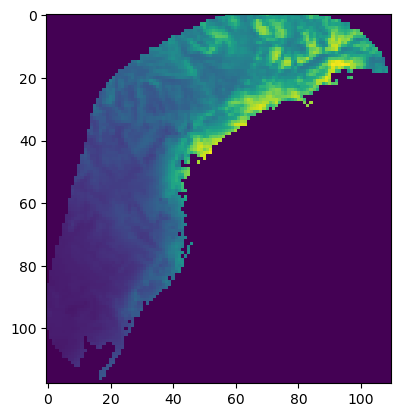

In [96]:
from matplotlib import pyplot

pyplot.imshow(k[0], cmap='viridis')

pyplot.show() 

In [98]:
m = stepping_stone2d(k[0], rate = 0.00001)

In [99]:
m = add_landscape_change(model = m, k_stack = k, timestep = 1000, rate = 0.00001)

In [100]:
# read in admixture ID raster
with rasterio.open(admix_id_out) as a:
    admix_r = a.read()

In [101]:
m = add_nonspatial_phase(m, 
                         ancestral_size_list=[2000000, 100000], 
                         merge_time=2200000, 
                         admix_id_rast=admix_r,  
                         ancestral_merge_size_list=[2000000], 
                         ancestral_merge_time_list=[4000000])

In [93]:
m.num_populations

12983

In [30]:
m.sort_events()

In [102]:
gen_path = "/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/data/vcfs/clust92_iheringii_0.6_nosingletons.vcf"

pop_dict_sim, pop_dict_sim_long, pop_dict_empirical = coords_to_sample_dict_empirical(r, coords, individual_ids=localities["id_code"], vcf_path=gen_path)

In [32]:
# 
# get populations with at least two individuals to sample for coalescent simulations
nzp = []

for i in range(len(m.populations)):
    if m.populations[i].initial_size >= 2.0 and "ANC" not in m.populations[i].name:
        nzp.append(m.populations[i].name)

pop_dict_all = {key: 2 for key in nzp}

pop_dict_all

{'pop_0_57': 2,
 'pop_0_58': 2,
 'pop_0_59': 2,
 'pop_0_60': 2,
 'pop_0_61': 2,
 'pop_0_62': 2,
 'pop_0_63': 2,
 'pop_0_64': 2,
 'pop_0_65': 2,
 'pop_0_66': 2,
 'pop_0_67': 2,
 'pop_0_68': 2,
 'pop_0_69': 2,
 'pop_0_70': 2,
 'pop_0_71': 2,
 'pop_0_72': 2,
 'pop_0_73': 2,
 'pop_0_74': 2,
 'pop_0_75': 2,
 'pop_0_76': 2,
 'pop_0_77': 2,
 'pop_0_78': 2,
 'pop_0_79': 2,
 'pop_0_80': 2,
 'pop_0_81': 2,
 'pop_0_82': 2,
 'pop_0_83': 2,
 'pop_0_84': 2,
 'pop_0_85': 2,
 'pop_0_86': 2,
 'pop_1_54': 2,
 'pop_1_55': 2,
 'pop_1_56': 2,
 'pop_1_57': 2,
 'pop_1_58': 2,
 'pop_1_59': 2,
 'pop_1_60': 2,
 'pop_1_61': 2,
 'pop_1_62': 2,
 'pop_1_63': 2,
 'pop_1_64': 2,
 'pop_1_65': 2,
 'pop_1_66': 2,
 'pop_1_67': 2,
 'pop_1_68': 2,
 'pop_1_69': 2,
 'pop_1_70': 2,
 'pop_1_71': 2,
 'pop_1_72': 2,
 'pop_1_73': 2,
 'pop_1_74': 2,
 'pop_1_75': 2,
 'pop_1_76': 2,
 'pop_1_77': 2,
 'pop_1_78': 2,
 'pop_1_79': 2,
 'pop_1_80': 2,
 'pop_1_81': 2,
 'pop_1_82': 2,
 'pop_1_83': 2,
 'pop_1_84': 2,
 'pop_1_85': 2,
 'pop_1_

In [33]:
admix_dict = admix_to_deme_dict(admix_id_out, pop_dict_empirical)
admix_dict

{1: [2704,
  2821,
  2825,
  2833,
  2924,
  2925,
  2937,
  3039,
  3135,
  3139,
  3146,
  3152,
  3252,
  3357,
  3800,
  3902,
  3913,
  4111,
  4114,
  4227,
  4237,
  4670,
  4671],
 2: [4892, 5000, 6527, 8725, 10257]}

In [103]:
ts = msprime.sim_ancestry(pop_dict_sim, 
                          sequence_length=1e6, 
                          demography = m, 
                          recombination_rate=1e-9, 
                          record_provenance=False)

In [ ]:
# try out multiple merger coalescent
ts = msprime.sim_ancestry(pop_dict_all, 
                          sequence_length=1e6, 
                          model=[
                              msprime.DiracCoalescent(duration=22000, psi = 0.1, c = 1),
                              msprime.StandardCoalescent(),
                              ],
                          demography = m, 
                          recombination_rate=1e-9, 
                          record_provenance=False)

In [104]:
mu = msprime.sim_mutations(ts, rate = 1e-9)

In [117]:
mu.num_mutations

45841

In [105]:
gc_unlinked, gc_unlinked_demes, gc_unlinked_admix = counts_from_ts(ts=mu, pops_dict_deme=pop_dict_sim_long, pops_dict_admix=admix_dict, missing_data_perc = 0.4, r2_thresh = 0.1, seed = 12345)

In [37]:
# allele counts matrices for empirical populations
gc_emp, gc_emp_demes, gc_emp_admix = counts_from_vcf(vcf=gen_path, pops_dict=pop_dict_empirical, pops_dict_admix=admix_dict, r2_thresh = 0.1)

In [38]:
coord_dict = sampled_cells_to_coords(r, coords)

In [121]:
import tskit
coal_list = []
# For each population
for j in range(mu.num_populations):
    # Get the samples corresponding to this population
    samples = mu.samples(population=j)
    # Simplify the tree sequence to just these samples
    ts_pop = mu.simplify(samples=samples)
    tree = ts_pop
    # take the first tree sequence
    #tree = ts_pop.first()
    # only calc diversity if there is at least one sample
    if tree.num_samples > 0:
        coal_list.append(mu.diversity(samples))
    else: coal_list.append(-1)

coal_1d = np.array(coal_list)[:-3]

coal_array = np.reshape(coal_1d, newshape = (118, 110))

In [106]:
coal_1d = np.array(coal_list)[:-3]

coal_array = np.reshape(coal_1d, newshape = (118, 110))

/var/folders/vf/3z__6c_11bb7b95dtcms1m0c0000gp/T/ipykernel_92453/3310097402.py:2: RuntimeWarning: invalid value encountered in log
  pyplot.imshow(np.log(coal_array))


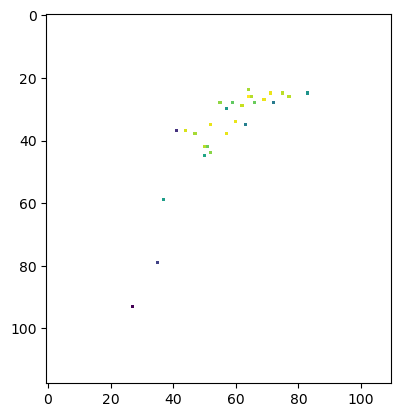

In [124]:
from matplotlib import pyplot
pyplot.imshow(np.log(coal_array))

In [125]:
coal_1d[admix_dict[1]] 

array([0.005316  , 0.006881  , 0.0056788 , 0.002183  , 0.007398  ,
       0.005594  , 0.00570033, 0.006862  , 0.004859  , 0.004008  ,
       0.004149  , 0.001704  , 0.00595996, 0.002279  , 0.006777  ,
       0.006793  , 0.001767  , 0.000865  , 0.006373  , 0.00524833,
       0.006736  , 0.0056415 , 0.004234  ])

In [104]:
ts.num_samples

90

In [110]:
# I get efficiency warnings for how I add to the pandas data frame. This takes only a couple seconds anyways, so I'm not worried about it
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sumstats= calc_sumstats(counts_array = gc_unlinked, demes_coordinates = coord_dict, admix_dict=admix_dict, counts_array_demes=gc_unlinked_demes, counts_array_admix=gc_unlinked_admix)
    sumstats_empirical = calc_sumstats(counts_array = gc_emp, demes_coordinates = coord_dict, admix_dict=admix_dict, counts_array_demes=gc_emp_demes, counts_array_admix=gc_emp_admix)

In [111]:
pd.set_option('display.max_columns', None)
sumstats

,sfs_h1_a1,sfs_h2_a1,sfs_h3_a1,pi_a1,pi_sd_a1,taj_d_a1,taj_d_sd_a1,sfs_h1_a2,sfs_h2_a2,sfs_h3_a2,pi_a2,pi_sd_a2,taj_d_a2,taj_d_sd_a2,pi_pop_2704,pi_pop_2821,pi_pop_2825,pi_pop_2833,pi_pop_2924,pi_pop_2925,pi_pop_2937,pi_pop_3039,pi_pop_3135,pi_pop_3139,pi_pop_3146,pi_pop_3152,pi_pop_3252,pi_pop_3357,pi_pop_3800,pi_pop_3902,pi_pop_3913,pi_pop_4111,pi_pop_4114,pi_pop_4227,pi_pop_4237,pi_pop_4670,pi_pop_4671,pi_pop_4892,pi_pop_5000,pi_pop_6527,pi_pop_8725,pi_pop_10257,dxy_2704_2821,fst_2704_2821,dxy_2704_2825,fst_2704_2825,dxy_2704_2833,fst_2704_2833,dxy_2704_2924,fst_2704_2924,dxy_2704_2925,fst_2704_2925,dxy_2704_2937,fst_2704_2937,dxy_2704_3039,fst_2704_3039,dxy_2704_3135,fst_2704_3135,dxy_2704_3139,fst_2704_3139,dxy_2704_3146,fst_2704_3146,dxy_2704_3152,fst_2704_3152,dxy_2704_3252,fst_2704_3252,dxy_2704_3357,fst_2704_3357,dxy_2704_3800,fst_2704_3800,dxy_2704_3902,fst_2704_3902,dxy_2704_3913,fst_2704_3913,dxy_2704_4111,fst_2704_4111,dxy_2704_4114,fst_2704_4114,dxy_2704_4227,fst_2704_4227,dxy_2704_4237,fst_2704_4237,dxy_2704_4670,fst_2704_4670,dxy_2704_4671,fst_2704_4671,dxy_2821_2825,fst_2821_2825,dxy_2821_2833,fst_2821_2833,dxy_2821_2924,fst_2821_2924,dxy_2821_2925,fst_2821_2925,dxy_2821_2937,fst_2821_2937,dxy_2821_3039,fst_2821_3039,dxy_2821_3135,fst_2821_3135,dxy_2821_3139,fst_2821_3139,dxy_2821_3146,fst_2821_3146,dxy_2821_3152,fst_2821_3152,dxy_2821_3252,fst_2821_3252,dxy_2821_3357,fst_2821_3357,dxy_2821_3800,fst_2821_3800,dxy_2821_3902,fst_2821_3902,dxy_2821_3913,fst_2821_3913,dxy_2821_4111,fst_2821_4111,dxy_2821_4114,fst_2821_4114,dxy_2821_4227,fst_2821_4227,dxy_2821_4237,fst_2821_4237,dxy_2821_4670,fst_2821_4670,dxy_2821_4671,fst_2821_4671,dxy_2825_2833,fst_2825_2833,dxy_2825_2924,fst_2825_2924,dxy_2825_2925,fst_2825_2925,dxy_2825_2937,fst_2825_2937,dxy_2825_3039,fst_2825_3039,dxy_2825_3135,fst_2825_3135,dxy_2825_3139,fst_2825_3139,dxy_2825_3146,fst_2825_3146,dxy_2825_3152,fst_2825_3152,dxy_2825_3252,fst_2825_3252,dxy_2825_3357,fst_2825_3357,dxy_2825_3800,fst_2825_3800,dxy_2825_3902,fst_2825_3902,dxy_2825_3913,fst_2825_3913,dxy_2825_4111,fst_2825_4111,dxy_2825_4114,fst_2825_4114,dxy_2825_4227,fst_2825_4227,dxy_2825_4237,fst_2825_4237,dxy_2825_4670,fst_2825_4670,dxy_2825_4671,fst_2825_4671,dxy_2833_2924,fst_2833_2924,dxy_2833_2925,fst_2833_2925,dxy_2833_2937,fst_2833_2937,dxy_2833_3039,fst_2833_3039,dxy_2833_3135,fst_2833_3135,dxy_2833_3139,fst_2833_3139,dxy_2833_3146,fst_2833_3146,dxy_2833_3152,fst_2833_3152,dxy_2833_3252,fst_2833_3252,dxy_2833_3357,fst_2833_3357,dxy_2833_3800,fst_2833_3800,dxy_2833_3902,fst_2833_3902,dxy_2833_3913,fst_2833_3913,dxy_2833_4111,fst_2833_4111,dxy_2833_4114,fst_2833_4114,dxy_2833_4227,fst_2833_4227,dxy_2833_4237,fst_2833_4237,dxy_2833_4670,fst_2833_4670,dxy_2833_4671,fst_2833_4671,dxy_2924_2925,fst_2924_2925,dxy_2924_2937,fst_2924_2937,dxy_2924_3039,fst_2924_3039,dxy_2924_3135,fst_2924_3135,dxy_2924_3139,fst_2924_3139,dxy_2924_3146,fst_2924_3146,dxy_2924_3152,fst_2924_3152,dxy_2924_3252,fst_2924_3252,dxy_2924_3357,fst_2924_3357,dxy_2924_3800,fst_2924_3800,dxy_2924_3902,fst_2924_3902,dxy_2924_3913,fst_2924_3913,dxy_2924_4111,fst_2924_4111,dxy_2924_4114,fst_2924_4114,dxy_2924_4227,fst_2924_4227,dxy_2924_4237,fst_2924_4237,dxy_2924_4670,fst_2924_4670,dxy_2924_4671,fst_2924_4671,dxy_2925_2937,fst_2925_2937,dxy_2925_3039,fst_2925_3039,dxy_2925_3135,fst_2925_3135,dxy_2925_3139,fst_2925_3139,dxy_2925_3146,fst_2925_3146,dxy_2925_3152,fst_2925_3152,dxy_2925_3252,fst_2925_3252,dxy_2925_3357,fst_2925_3357,dxy_2925_3800,fst_2925_3800,dxy_2925_3902,fst_2925_3902,dxy_2925_3913,fst_2925_3913,dxy_2925_4111,fst_2925_4111,dxy_2925_4114,fst_2925_4114,dxy_2925_4227,fst_2925_4227,dxy_2925_4237,fst_2925_4237,dxy_2925_4670,fst_2925_4670,dxy_2925_4671,fst_2925_4671,dxy_2937_3039,fst_2937_3039,dxy_2937_3135,fst_2937_3135,dxy_2937_3139,fst_2937_3139,dxy_2937_3146,fst_2937_3146,dxy_2937_3152,fst_2937_3152,dxy_2937_3252,fst_2937_3252,dxy_2937_3357,fst_2937_3357,dxy_2937_3800,fst_2937_3800,dxy_2937_3902,fst_2937_3902,dx

In [109]:
sumstats.shape

(1, 576)

In [112]:
pd.set_option('display.max_columns', None)
sumstats_empirical

,sfs_h1_a1,sfs_h2_a1,sfs_h3_a1,pi_a1,pi_sd_a1,taj_d_a1,taj_d_sd_a1,sfs_h1_a2,sfs_h2_a2,sfs_h3_a2,pi_a2,pi_sd_a2,taj_d_a2,taj_d_sd_a2,pi_pop_2704,pi_pop_2821,pi_pop_2825,pi_pop_2833,pi_pop_2924,pi_pop_2925,pi_pop_2937,pi_pop_3039,pi_pop_3135,pi_pop_3139,pi_pop_3146,pi_pop_3152,pi_pop_3252,pi_pop_3357,pi_pop_3800,pi_pop_3902,pi_pop_3913,pi_pop_4111,pi_pop_4114,pi_pop_4227,pi_pop_4237,pi_pop_4670,pi_pop_4671,pi_pop_4892,pi_pop_5000,pi_pop_6527,pi_pop_8725,pi_pop_10257,dxy_2704_2821,fst_2704_2821,dxy_2704_2825,fst_2704_2825,dxy_2704_2833,fst_2704_2833,dxy_2704_2924,fst_2704_2924,dxy_2704_2925,fst_2704_2925,dxy_2704_2937,fst_2704_2937,dxy_2704_3039,fst_2704_3039,dxy_2704_3135,fst_2704_3135,dxy_2704_3139,fst_2704_3139,dxy_2704_3146,fst_2704_3146,dxy_2704_3152,fst_2704_3152,dxy_2704_3252,fst_2704_3252,dxy_2704_3357,fst_2704_3357,dxy_2704_3800,fst_2704_3800,dxy_2704_3902,fst_2704_3902,dxy_2704_3913,fst_2704_3913,dxy_2704_4111,fst_2704_4111,dxy_2704_4114,fst_2704_4114,dxy_2704_4227,fst_2704_4227,dxy_2704_4237,fst_2704_4237,dxy_2704_4670,fst_2704_4670,dxy_2704_4671,fst_2704_4671,dxy_2821_2825,fst_2821_2825,dxy_2821_2833,fst_2821_2833,dxy_2821_2924,fst_2821_2924,dxy_2821_2925,fst_2821_2925,dxy_2821_2937,fst_2821_2937,dxy_2821_3039,fst_2821_3039,dxy_2821_3135,fst_2821_3135,dxy_2821_3139,fst_2821_3139,dxy_2821_3146,fst_2821_3146,dxy_2821_3152,fst_2821_3152,dxy_2821_3252,fst_2821_3252,dxy_2821_3357,fst_2821_3357,dxy_2821_3800,fst_2821_3800,dxy_2821_3902,fst_2821_3902,dxy_2821_3913,fst_2821_3913,dxy_2821_4111,fst_2821_4111,dxy_2821_4114,fst_2821_4114,dxy_2821_4227,fst_2821_4227,dxy_2821_4237,fst_2821_4237,dxy_2821_4670,fst_2821_4670,dxy_2821_4671,fst_2821_4671,dxy_2825_2833,fst_2825_2833,dxy_2825_2924,fst_2825_2924,dxy_2825_2925,fst_2825_2925,dxy_2825_2937,fst_2825_2937,dxy_2825_3039,fst_2825_3039,dxy_2825_3135,fst_2825_3135,dxy_2825_3139,fst_2825_3139,dxy_2825_3146,fst_2825_3146,dxy_2825_3152,fst_2825_3152,dxy_2825_3252,fst_2825_3252,dxy_2825_3357,fst_2825_3357,dxy_2825_3800,fst_2825_3800,dxy_2825_3902,fst_2825_3902,dxy_2825_3913,fst_2825_3913,dxy_2825_4111,fst_2825_4111,dxy_2825_4114,fst_2825_4114,dxy_2825_4227,fst_2825_4227,dxy_2825_4237,fst_2825_4237,dxy_2825_4670,fst_2825_4670,dxy_2825_4671,fst_2825_4671,dxy_2833_2924,fst_2833_2924,dxy_2833_2925,fst_2833_2925,dxy_2833_2937,fst_2833_2937,dxy_2833_3039,fst_2833_3039,dxy_2833_3135,fst_2833_3135,dxy_2833_3139,fst_2833_3139,dxy_2833_3146,fst_2833_3146,dxy_2833_3152,fst_2833_3152,dxy_2833_3252,fst_2833_3252,dxy_2833_3357,fst_2833_3357,dxy_2833_3800,fst_2833_3800,dxy_2833_3902,fst_2833_3902,dxy_2833_3913,fst_2833_3913,dxy_2833_4111,fst_2833_4111,dxy_2833_4114,fst_2833_4114,dxy_2833_4227,fst_2833_4227,dxy_2833_4237,fst_2833_4237,dxy_2833_4670,fst_2833_4670,dxy_2833_4671,fst_2833_4671,dxy_2924_2925,fst_2924_2925,dxy_2924_2937,fst_2924_2937,dxy_2924_3039,fst_2924_3039,dxy_2924_3135,fst_2924_3135,dxy_2924_3139,fst_2924_3139,dxy_2924_3146,fst_2924_3146,dxy_2924_3152,fst_2924_3152,dxy_2924_3252,fst_2924_3252,dxy_2924_3357,fst_2924_3357,dxy_2924_3800,fst_2924_3800,dxy_2924_3902,fst_2924_3902,dxy_2924_3913,fst_2924_3913,dxy_2924_4111,fst_2924_4111,dxy_2924_4114,fst_2924_4114,dxy_2924_4227,fst_2924_4227,dxy_2924_4237,fst_2924_4237,dxy_2924_4670,fst_2924_4670,dxy_2924_4671,fst_2924_4671,dxy_2925_2937,fst_2925_2937,dxy_2925_3039,fst_2925_3039,dxy_2925_3135,fst_2925_3135,dxy_2925_3139,fst_2925_3139,dxy_2925_3146,fst_2925_3146,dxy_2925_3152,fst_2925_3152,dxy_2925_3252,fst_2925_3252,dxy_2925_3357,fst_2925_3357,dxy_2925_3800,fst_2925_3800,dxy_2925_3902,fst_2925_3902,dxy_2925_3913,fst_2925_3913,dxy_2925_4111,fst_2925_4111,dxy_2925_4114,fst_2925_4114,dxy_2925_4227,fst_2925_4227,dxy_2925_4237,fst_2925_4237,dxy_2925_4670,fst_2925_4670,dxy_2925_4671,fst_2925_4671,dxy_2937_3039,fst_2937_3039,dxy_2937_3135,fst_2937_3135,dxy_2937_3139,fst_2937_3139,dxy_2937_3146,fst_2937_3146,dxy_2937_3152,fst_2937_3152,dxy_2937_3252,fst_2937_3252,dxy_2937_3357,fst_2937_3357,dxy_2937_3800,fst_2937_3800,dxy_2937_3902,fst_2937_3902,dx

In [113]:
sumstats_empirical.to_csv("/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/empirical_sumstats/iheringii_sumstats.csv")

In [58]:
gc_unlinked_demes

AttributeError: 'dict' object has no attribute 'names'

In [60]:
num, den = allel.hudson_fst(gc_unlinked_demes[2704], gc_unlinked_demes[4111])

np.nansum(num) / np.nansum(den)

0.8083977900552485

array([0.2, 0. , 0.2, ..., 0. , 0. , 0. ])

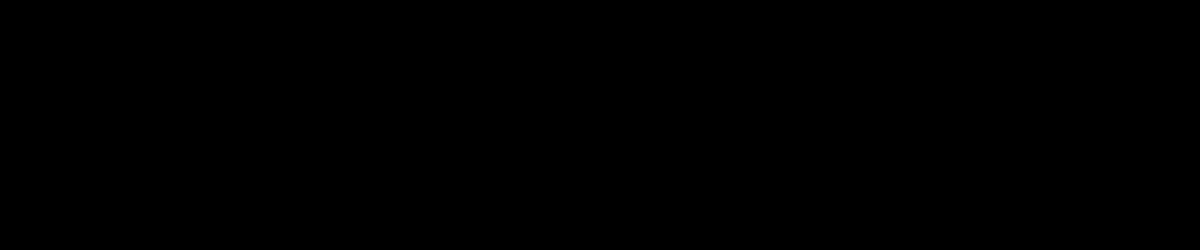

In [126]:

wide_fmt = (1200, 250)
# Create a stylesheet that shrinks labels and rotates leaf labels, to avoid overlap
node_label_style = (
    ".node > .lab {font-size: 80%}"
    ".leaf > .lab {text-anchor: start; transform: rotate(90deg) translate(6px)}"
)
mu.first().draw_svg(
    size=wide_fmt,
    time_scale="log_time",
    y_gridlines=True,
    y_axis=True,
    y_ticks=[1, 10, 100, 1000, 10000, 100000],
    style=node_label_style,
)

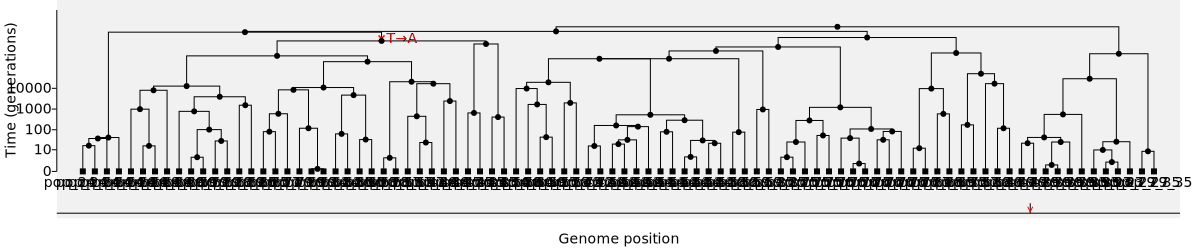

In [52]:
x_limits = [100000, 100015]
# Create evenly-spaced y tick positions to avoid overlap
y_tick_pos = [0, 10, 100, 1000, 10000]
wide_fmt = (1200, 250)
# Create a stylesheet that shrinks labels and rotates leaf labels, to avoid overlap
node_label_style = (
    ".node > .lab {font-size: 80%}"
    ".leaf > .lab {text-anchor: start; transform: rotate(90deg) translate(6px)}"
)


nd_labels = {}  # An array of labels for the nodes
for n in mu.nodes():
    # Set sample node labels from metadata. Here we use the population name, but you might want
    # to use the *individual* name instead, if the individuals in your tree sequence have names
    if n.is_sample():
        nd_labels[n.id] = mu.population(n.population).metadata["name"]

mut_labels = {}  # An array of labels for the mutations
for mut in mu.mutations():  # Make pretty labels showing the change in state
    site = mu.site(mut.site)
    older_mut = mut.parent >= 0  # is there an older mutation at the same position?
    prev = mu.mutation(mut.parent).derived_state if older_mut else site.ancestral_state
    mut_labels[mut.id] = f"{prev}→{mut.derived_state}"

mu.draw_svg(
    y_axis=True, y_ticks=y_tick_pos, x_lim=x_limits,
    size = wide_fmt,
    time_scale="log_time",
    node_labels=nd_labels,
    mutation_labels=mut_labels,
)

In [270]:
mu.get_samples(3152)

array([34, 35], dtype=int32)

In [271]:
mu.individual_populations[17]

3152

In [135]:
np.geomspace(100, 5000, 10,  dtype = int)

array([ 100,  154,  238,  368,  568,  878, 1357, 2096, 3237, 5000])

In [130]:
mu.num_mutations

45841

In [440]:
np.linspace(1e5, 2e6, 10, dtype=int)

array([ 100000,  311111,  522222,  733333,  944444, 1155555, 1366666,
       1577777, 1788888, 2000000])

In [441]:
mu.populations()[6527]

Population(id=6527, metadata={'description': '', 'name': 'pop_59_37'})

In [280]:
1e-9 * ts.diversity(sample_sets=[34, 35], mode="branch", span_normalise=True)

1.0611842982965073e-08

In [282]:
mu.diversity(sample_sets=[34, 35], span_normalise=False)

0.0

In [178]:
windows = np.linspace(0, ts.sequence_length, num=100)
d = ts.diversity(sample_sets=[6,7], windows=windows)
print(windows, d, sep="\n")

[       0.           101010.1010101    202020.2020202    303030.3030303
   404040.4040404    505050.50505051   606060.60606061   707070.70707071
   808080.80808081   909090.90909091  1010101.01010101  1111111.11111111
  1212121.21212121  1313131.31313131  1414141.41414141  1515151.51515152
  1616161.61616162  1717171.71717172  1818181.81818182  1919191.91919192
  2020202.02020202  2121212.12121212  2222222.22222222  2323232.32323232
  2424242.42424242  2525252.52525253  2626262.62626263  2727272.72727273
  2828282.82828283  2929292.92929293  3030303.03030303  3131313.13131313
  3232323.23232323  3333333.33333333  3434343.43434343  3535353.53535354
  3636363.63636364  3737373.73737374  3838383.83838384  3939393.93939394
  4040404.04040404  4141414.14141414  4242424.24242424  4343434.34343434
  4444444.44444444  4545454.54545454  4646464.64646465  4747474.74747475
  4848484.84848485  4949494.94949495  5050505.05050505  5151515.15151515
  5252525.25252525  5353535.35353535  5454545.454545

In [99]:

# get total the number of elements in the genotype matrix
total_array_size = mu.genotype_matrix().shape[0] * ts.genotype_matrix().shape[1]

# fill an array with zeros that is the total size of the original matrix
a = np.zeros(total_array_size, dtype=int)

# set the first x elements to be the size of non-missing data
non_miss = int(np.ceil(total_array_size * (1 - 0.4)))

# 1 means "True"
a[:non_miss] = 1

# randomly shuffle True and False values
np.random.shuffle(a)

# transform to boolean
a = a.astype(bool)

# reshape to genotype matrix shape
miss_mask = np.reshape(a, mu.genotype_matrix().shape)

# mask the genotype matrix
geno_mat = np.ma.masked_array(mu.genotype_matrix(), mask=miss_mask, fill_value=-1)

# convert to a GenotypeArray
h = allel.HaplotypeArray(geno_mat)

gt = h.to_genotypes(ploidy = 2)

gt.shape

(15410, 45, 2)

In [284]:
np.linspace(100000, 2e6, 10, dtype = int)

array([ 100000,  311111,  522222,  733333,  944444, 1155555, 1366666,
       1577777, 1788888, 2000000])

In [165]:
gc = gt.to_allele_counts(max_allele=1)

ac = gc.count_alleles(subpop = [8])

np.nanmean(allel.mean_pairwise_difference(ac, fill = np.nan))

np.count_nonzero(np.isnan(allel.mean_pairwise_difference(ac, fill = np.nan)))

29

In [134]:
with open("/Users/connorfrench/Downloads/zero_ac.csv", "w") as f:
    np.savetxt(f, np.array(ac), delimiter=",")

In [98]:
with open("/Users/connorfrench/Downloads/ex_genomat.csv", "w") as f:
    np.savetxt(f, np.int16(genomat[:,6:8]), delimiter=",")

In [84]:
ihe_vcf = allel.read_vcf(gen_path)

In [74]:
max_thresh = 0.1
# parameter combinations
n_p = 5
#n_thresh = 3
max_k = np.linspace(100, 5000, n_p * 2,  dtype = int)
#max_k = [700]
recomb_rate = [1e-9]
#mut_rate = [1e-9]
Nm = np.geomspace(0.1, 5, n_p)
#Nm = [1]
#thresh = np.linspace(max_thresh / 4, max_thresh, n_thresh)
# spatial merge time
sp_merge_time_list = [22000]

thresh = max_thresh

ancestral_size_a1 = np.linspace(1e6, 3e6, n_p, dtype=int)

ancestral_size_a2 = np.linspace(5e4, 5e5, n_p, dtype=int)

ancestral_size_list = []

for i in range(len(ancestral_size_a1)):
    for j in range(len(ancestral_size_a2)):
        if ancestral_size_a1[i] > ancestral_size_a2[j]:
            asize = [ancestral_size_a1[i], ancestral_size_a2[j]]
            ancestral_size_list.append(asize)

#ancestral_merge_size_list = [[ancestral_size_a1[i]] for i in range(len(ancestral_size_a1))]

ancestral_merge_time_list = [[1000000]]

## missing data percentage to correspond with empirical data
miss_data = 0.4

# make list of parameter combinations to iterate over
lin_sim_params = list(itertools.product(*[
    max_k, 
    Nm, 
    ancestral_size_list, 
    #ancestral_merge_size_list, 
    ancestral_merge_time_list, 
    recomb_rate, 
    [0],
    sp_merge_time_list]))#hinge_sim_params = list(itertools.product(*[max_k, Nm, ancestral_n_multiplier, recomb_rate, mut_rate, thresh]))

len(lin_sim_params)

1250

In [82]:
mid_ind = len(lin_sim_params) // 2
lin_sim_params_first = [lin_sim_params[i] for i in range(mid_ind + 1)]
lin_sim_params_second = [lin_sim_params[i] for i in range(mid_ind, len(lin_sim_params))]

# ### linear sims
num_param_combos = len(lin_sim_params_second)
sims_per_process = num_param_combos // 30
if num_param_combos % 30 > 0:
    sims_per_process += 1

sims_per_process

21

65625

In [1076]:
localities[["longitude", "latitude", "id_code", "admix_ids"]][localities["id_code"] == "ihe_grao_MTR33258"]

,longitude,latitude,id_code,admix_ids
145,-49.35863,-28.07171,ihe_grao_MTR33258,2


In [913]:
np.savetxt("/Users/connorfrench/Downloads/pos.txt", ihe_vcf["variants/POS"])

In [1013]:
pi, _, _, nvar = allel.windowed_diversity(pos=list(range(gc_emp.shape[0])), ac = gc_emp_admix[1], size = 50, step = 10)

(array([9.927e+03, 9.244e+03, 2.931e+03, 1.126e+03, 9.760e+02, 5.840e+02,
        2.540e+02, 1.000e+02, 2.100e+01, 4.000e+00]),
 array([0.        , 0.00983029, 0.01966058, 0.02949087, 0.03932117,
        0.04915146, 0.05898175, 0.06881204, 0.07864233, 0.08847262,
        0.09830291]),
 <BarContainer object of 10 artists>)

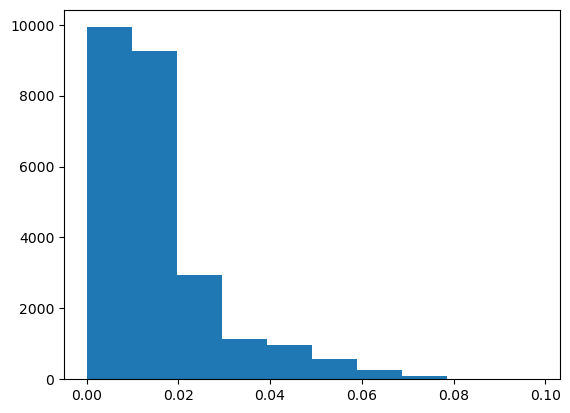

In [1014]:
from matplotlib import pyplot as plt

plt.hist(pi)

In [1003]:
np.nanmean(pi)

0.015539494480822093

In [1015]:
sumstat_empirical["fst_a1_2"]

0    0.026213
Name: fst_a1_2, dtype: float64

In [153]:

# parameter combinations
n_p = 5

# n_thresh = 3

max_k = np.linspace(100, 5000, n_p * 2,  dtype = int)

recomb_rate = [1e-9]

mut_rates =  np.linspace(1e-9, 1e-10, n_p)

Nm = np.geomspace(0.1, 5, n_p)

# spatial merge time
sp_merge_time_list = [22000]

thresh = 0

ancestral_size_a1 = np.linspace(1e6, 3e6, n_p, dtype=int)

ancestral_size_a2 = np.linspace(1e5, 5e5, n_p, dtype=int)

ancestral_size_list = []

for i in range(len(ancestral_size_a1)):
    for j in range(len(ancestral_size_a2)):
        if ancestral_size_a1[i] > ancestral_size_a2[j]:
            asize = [ancestral_size_a1[i], ancestral_size_a2[j]]
            ancestral_size_list.append(asize)

#ancestral_merge_size_list = [[ancestral_size_a1[i]] for i in range(len(ancestral_size_a1))]

ancestral_merge_time_list = [[1000000]]

## missing data percentage to correspond with empirical data
miss_data = 0.4

# make list of parameter combinations to iterate over
lin_sim_params = list(itertools.product(*[
    max_k, 
    Nm, 
    ancestral_size_list, 
    #ancestral_merge_size_list, 
    ancestral_merge_time_list, 
    recomb_rate, 
    [0],
    sp_merge_time_list]))

len(lin_sim_params) * 5

6250

In [ ]:
# 8.075260718424094e-06
np.nanmean(div_mat)

In [ ]:
from matplotlib import pyplot

pyplot.hist(np.ravel(div_mat))

pyplot.show() 

In [ ]:
from matplotlib import pyplot

pyplot.imshow(div_mat, cmap='RdBu')

pyplot.show() 

In [ ]:
div_mat[0:10, 0:10]

## Testing simulations with pre-specified matrices

In [ ]:
import numpy as np
k = np.random.randint(0, 10, (2, 5, 5))
k


In [ ]:

m = stepping_stone2d(k[0], rate = 0.001)

m = add_landscape_change(model = m, k_stack = k, timestep = 1000)

m = add_nonspatial_phase(m, ancestral_size=1e6, merge_time=21000)

m.sort_events()

# get populations with at least two individuals to sample for coalescent simulations
nzp = []
for i in range(len(m.populations)):
    if m.populations[i].initial_size >= 2.0 and m.populations[i].name != "ANC":
        nzp.append(m.populations[i].name)

pop_dict = {key: 2 for key in nzp}

ts = msprime.sim_ancestry(pop_dict, sequence_length=1e6, demography = m, recombination_rate=1e-9, record_provenance=False)

ts = msprime.sim_mutations(ts, rate = 1e-7)

In [ ]:
div_mat = get_diversity_matrix(ts, k[0].shape)

In [ ]:
from matplotlib import pyplot

pyplot.imshow(div_mat, cmap='RdBu')

pyplot.show() 

### Debug parent node <= child node error

In [ ]:
def sim(k, num_layers, ancestral_ne, recomb_rate, mig_rate = 0.001):
    m = stepping_stone2d(k[0], rate = mig_rate)

    m = add_landscape_change(model = m, k_stack = k[0:num_layers], timestep = 1000)

    m = add_nonspatial_phase(m, ancestral_size=ancestral_ne, merge_time=num_layers * 1000 + 1000)

    m.sort_events()

    # get populations with at least two individuals to sample for coalescent simulations
    nzp = []
    for i in range(len(m.populations)):
        if m.populations[i].initial_size >= 2.0 and m.populations[i].name != "ANC":
            nzp.append(m.populations[i].name)

    pop_dict = {key: 2 for key in nzp}

    ts = msprime.sim_ancestry(pop_dict, sequence_length=1e6, demography = m, recombination_rate=recomb_rate, record_provenance=False)

    return f"num_layers = {num_layers}, ancestral_ne = {ancestral_ne}, recomb_rate = {recomb_rate}, success = Yes\n"



In [ ]:
def sim_ts(k, num_layers, ancestral_ne, recomb_rate, sample_dict=False, mig_rate = 0.001, tstep = 1000):
    m = stepping_stone2d(k[0], rate = mig_rate)

    m = add_landscape_change(model = m, k_stack = k[0:num_layers], rate=mig_rate, timestep = tstep)

    m = add_nonspatial_phase(m, ancestral_size=ancestral_ne, merge_time=num_layers * 1000 + 1000)

    m.sort_events()

    if sample_dict:
        pop_dict = sample_dict
    else:
        # get populations with at least two individuals to sample for coalescent simulations
        nzp = []
        
        for i in range(len(m.populations)):
            if m.populations[i].initial_size >= 2.0 and m.populations[i].name != "ANC":
                nzp.append(m.populations[i].name)

        pop_dict = {key: 2 for key in nzp}

    ts = msprime.sim_ancestry(pop_dict, sequence_length=1e6, demography = m, recombination_rate=recomb_rate, record_provenance=False)

    return ts

In [529]:
# setup demography for debugging
def setup_demography(k, num_layers, ancestral_ne, mig_rate = 0.001, scale=True):
    m = stepping_stone2d(k[0], rate = mig_rate, scale = scale)

    m = add_landscape_change(model = m, k_stack = k[0:num_layers], rate=mig_rate, timestep = 1000)

    m = add_nonspatial_phase(m, ancestral_size=ancestral_ne, merge_time=num_layers * 1000 + 1000)

    m.sort_events()

    return m


In [ ]:
# read in rasters and convert to K
import rasterio

filepath = "/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/sdm_projections/projections_ihe_10km.tif"

with rasterio.open(filepath) as src:
    print(src.profile)
    r = src.read(masked=True)


k = raster_to_k(r, transformation="linear", max_local_k = 100)

#### Experiment 1
I looped through the following parameter combination to see if there were any patterns:
- ancestral Ne = \[5000, 50000, 500000\]
- recombination = \[0, 1e-9]
- number of layers = \[3, 5, 10]

There was no pattern.

In [ ]:
# loop through parameters and write the status to a file
for nl in [3, 5, 10]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = k, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss.txt', 'a') as f:
                    f.write(failure)

#### Experiment 2

I looped through the following parameter combination to see if there were any patterns:
- ancestral Ne = \[5000, 50000, 500000\]
- recombination = \[0, 1e-9]
- number of layers = 1

All ran successfully with 1 layer.

In [ ]:
# loop through parameters and write the status to a file
for nl in [1]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = k, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_k1.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_k1.txt', 'a') as f:
                    f.write(failure)

#### Experiment 3

I'm going to split the landscape in half, then see if a particular half has trouble. I'll probably continue this into smaller pieces until I find the smallest piece where I can recreate the error. I'm going to do the experiment for 3 layers, since it doesn't appear that the number of layers matters.

##### E3P1
Top half: This results in an error. Going to split it into a quarter.

In [ ]:
# split K in half vertically
khalf = k[:, 0:59, :]
from matplotlib import pyplot

pyplot.imshow(khalf[0], cmap='RdBu')

pyplot.show() 

In [ ]:
for nl in [3]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = khalf, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_tophalf.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_tophalf.txt', 'a') as f:
                    f.write(failure)

##### E3P2
Top-right quarter

One parameter combo failed, but I had to run it twice, as the first round had all successes- probably due to random chance.

In [ ]:
# top right quarter
ktr = k[:, 0:59, 56:]
from matplotlib import pyplot

pyplot.imshow(ktr[0], cmap='RdBu')

pyplot.show() 


In [ ]:
for nl in [3]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = ktr, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright.txt', 'a') as f:
                    f.write(failure)

##### E3P3
Top-left 10 x 10 of top-right quarter

All successes afrer quite a few repetitions. So, no problems here.

In [ ]:
# top right quarter
kten = ktr[:, 0:10, 0:10]
from matplotlib import pyplot

pyplot.imshow(kten[0], cmap='RdBu')

pyplot.show() 

In [ ]:
# I'm repeating this a few times to account for random chance of success/failure
for nl in [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = kten, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright10.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright10.txt', 'a') as f:
                    f.write(failure)

##### E3P4
Top-left 20 by 20 of top-right quadrant

Maybe there need to be more cells. Going to try this before moving to different section of the quadrant.

This resulted in some failures. I'll try the bottom half to narrow it down further. 

In [ ]:
# top right quarter
ktwenty = ktr[:, 0:20, 0:20]
from matplotlib import pyplot

pyplot.imshow(ktwenty[0], cmap='RdBu')

pyplot.show() 

In [ ]:
# I'm repeating this a few times to account for random chance of success/failure
for nl in [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = ktwenty, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright20.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright20.txt', 'a') as f:
                    f.write(failure)

##### E3P4
Bottom half of the top-left 20 by 20 of top-right quadrant. That's a doozy.

This had some failures too! Time to get the left half.

In [ ]:
k20b = ktwenty[:, 11:, :]
from matplotlib import pyplot

pyplot.imshow(k20b[0], cmap='RdBu')

pyplot.show() 

In [ ]:
# I'm repeating this a few times to account for random chance of success/failure
for nl in [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = k20b, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright20bhalf.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright20bhalf.txt', 'a') as f:
                    f.write(failure)

##### E3P5
Left half of the bottom half of the top-left 20 by 20 of top-right quadrant. That's an even bigger doozy.
After 132 reps, had a single failure. 

In [ ]:
k20b10 = ktwenty[:, 11:, 0:10]
k20b10thousand = k20b10 * 1000

from matplotlib import pyplot

pyplot.imshow(k20b10[0], cmap='RdBu')

pyplot.show() 

In [ ]:
# I'm repeating this a few times to account for random chance of success/failure
for nl in [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]:
    for ne in [5000, 50000, 500000]:
        for rr in [0, 1e-9]:
            try:
                success = sim(k = k20b10, num_layers = nl, ancestral_ne = ne, recomb_rate = rr)
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright20bhalf10.txt', 'a') as f:
                    f.write(success)
            except Exception as e:
                er = str(e)
                failure = f"num_layers = {nl}, ancestral_ne = {ne}, recomb_rate = {rr}, success = No, error = {er}\n"
                with open('/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_topright20bhalf10.txt', 'a') as f:
                    f.write(failure)

##### Create a minimum example to put on github
Reducing the parameters needed to explore that reproduces the error for github.

In [ ]:
# I'm repeating this a few times to account for random chance of success/failure
outfile = '/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_github3.txt'

for nl in [3] * 200:
    try:
        success = sim(k = k20b10, num_layers = nl, ancestral_ne = 50000, recomb_rate = 0, mig_rate = 0.01)
        with open(outfile, 'a') as f:
            f.write(success)
    except Exception as e:
        er = str(e)
        failure = f"num_layers = {nl}, ancestral_ne = 50000, recomb_rate = 0, success = No, error = {er}\n"
        with open(outfile, 'a') as f:
            f.write(failure)

In [ ]:
k1 = ktwenty


k1[k1 == 0] = 1

k1

In [ ]:
# I'm repeating this a few times to account for random chance of success/failure
outfile = '/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_github_ktwenty1.txt'

for nl in [5] * 200:
    try:
        success = sim(k = k1, num_layers = nl, ancestral_ne = 50000, recomb_rate = 0)
        with open(outfile, 'a') as f:
            f.write(success)
    except Exception as e:
        er = str(e)
        failure = f"num_layers = {nl}, ancestral_ne = 50000, recomb_rate = 0, success = No, error = {er}\n"
        with open(outfile, 'a') as f:
            f.write(failure)

In [ ]:
ktry = np.load("/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/kmat.npy")
ktry

#### Experiment 4

Using the DemographyDebugger to diagnose the simulation problems. 

In [ ]:
from matplotlib import pyplot

pyplot.imshow(k20b10[0], cmap='RdBu')
pyplot.show() 

pyplot.imshow(k20b10[1], cmap='RdBu')
pyplot.show() 

pyplot.imshow(k20b10[2], cmap='RdBu')
pyplot.show() 

In [ ]:
# using the k20b10 array as the smallest reproducible example

dd = setup_demography(k = k20b10, num_layers = 3, ancestral_ne = 5000, recomb_rate = 0, mig_rate = 0.01)

In [ ]:
debugger = dd.debug()

In [ ]:
lprobs = debugger.lineage_probabilities([1, 5, 50, 100, 500, 1000, 1500, 2000, 2500])

In [ ]:
from matplotlib import pyplot

pyplot.imshow(lprobs[0], cmap='RdBu')

pyplot.show() 

In [ ]:
from matplotlib import pyplot

pyplot.hist(lprobs[4].ravel())

pyplot.show() 

I'm having trouble understanding exactly what I would expect, so I need to have a baseline to compare to. I'm going to simulate matrices with many individuals to see how the lineage probability matrix between different timepoints changes.

In [ ]:
np.random.seed(1820)
krand1 = np.random.randint(100, 200, size = 1000)
krand1 = krand1.astype(np.float32)
krand1 = np.append(krand1, [10e-10] * 300)
ksim1 = np.random.choice(krand1, (3, 5, 5))

ddsim1 = setup_demography(k = ksim1, num_layers = 3, ancestral_ne = 5000, recomb_rate = 0, mig_rate = 0.001)

debugger1 = ddsim1.debug()

#lprobs1 = debugger1.lineage_probabilities([1, 500, 1001, 1500, 2001, 2500])

In [ ]:
from matplotlib import pyplot

pyplot.imshow(ksim1[0], cmap='RdBu')
pyplot.show() 

pyplot.imshow(ksim1[1], cmap='RdBu')
pyplot.show() 

pyplot.imshow(ksim1[2], cmap='RdBu')
pyplot.show() 

In [ ]:
from matplotlib import pyplot

pyplot.imshow(lprobs1[3], cmap='RdBu')

pyplot.show() 

How does having larger population sizes impact simulation success?

In [ ]:
# I'm repeating this a few times to account for random chance of success/failure
outfile = '/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_ksim1_2.txt'

for nl in [3] * 200:
    try:
        success = sim(k = ksim1, num_layers = nl, ancestral_ne = 50000, recomb_rate = 0, mig_rate = 0.1)
        with open(outfile, 'a') as f:
            f.write(success)
    except Exception as e:
        er = str(e)
        failure = f"num_layers = {nl}, ancestral_ne = 50000, recomb_rate = 0, success = No, error = {er}\n"
        with open(outfile, 'a') as f:
            f.write(failure)

In [ ]:
ts = sim_ts(k = ksim1, num_layers = nl, ancestral_ne = 50000, recomb_rate = 0, mig_rate = 0.01)

In [ ]:
print(ts)

In [ ]:
from IPython.display import SVG, display
display(ts.draw_svg(y_axis=True, size = (1000, 1200), time_scale = "log_time"))

## Theoretical checks *a la* gridCoal

### Uniform population size

In [ ]:
deme_sizes = [10, 50, 100, 250, 500]
fw_mig = [10e-5, 10e-3, 10e-2, 10e-1, 1]

In [ ]:
import numpy as np

k_mats = []
for d in range(len(deme_sizes)):
    k_mats.append(np.full((30, 30), deme_sizes[d]))

In [ ]:
# from 
def get_coalescence_times(sim_results, subpops, file1):
    """Extracting results of the simulations."""
    tree = sim_results.first()
    sime_res_simple = sim_results.simplify().first()
    pop_length = len(subpops)

    result = []
    result = np.zeros((pop_length, pop_length))

    for i in range(pop_length):
        for j in range(pop_length):
            if i != j:
                result[i,j] = (sime_res_simple.tmrca(subpops[i][1], subpops[j][1]) + 
                               sime_res_simple.tmrca(subpops[i][0], subpops[j][0]) + 
                               sime_res_simple.tmrca(subpops[i][0], subpops[j][1]) + 
                               sime_res_simple.tmrca(subpops[i][1], subpops[j][0])) / 4
            else:
                result[i, j] = sime_res_simple.tmrca(subpops[i][0], subpops[j][1])
    return result

In [ ]:
def sim_ts_gridCoal(k, num_layers, ancestral_ne, recomb_rate, mig_rate = 0.001):
    m = stepping_stone2d(k, rate = mig_rate)

    m = add_landscape_change(model = m, k_stack = k[0:num_layers], timestep = 1000)

    m = add_nonspatial_phase(m, ancestral_size=ancestral_ne, merge_time=num_layers * 1000 + 1000)

    m.sort_events()

    # get populations with at least two individuals to sample for coalescent simulations
    nzp = []
    for i in range(len(m.populations)):
        if m.populations[i].initial_size >= 2.0 and m.populations[i].name != "ANC":
            nzp.append(m.populations[i].name)

    pop_dict = {key: 2 for key in nzp}

    ts = msprime.sim_ancestry(pop_dict, sequence_length=1e6, demography = m, recombination_rate=recomb_rate, record_provenance=False)

    return ts

Mig rate = 0

In [ ]:
ts_list_m0 = []

for k in range(len(k_mats)):
    ts = sim_ts_gridCoal(k = k_mats[k], num_layers = 1, ancestral_ne = 1, recomb_rate = 0, mig_rate = 0)
    ts_list_m0.append(ts)

In [ ]:
div_list_m0 = []

for t in ts_list_m0:
    div_list_m0.append(t.diversity(mode="branch"))

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(deme_sizes, div_list_m0)
plt.show()

In [ ]:
avg_tmrca_list = []
for t in ts_list_m0:
    tmrca_list = []
    # For each population
    for j in range(t.num_populations):
        # Get the samples corresponding to this population
        samples = t.samples(population=j)
        # Simplify the tree sequence to just these samples
        ts_pop = t.simplify(samples=samples)
        tree = ts_pop.first()
        try:
            tmrca = tree.time(tree.root)
            tmrca_list.append(tmrca)
            
        except: 
            print("no tree")
    avg_tmrca_list.append(np.mean(tmrca_list))
    

In [ ]:
avg_tmrca_list

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(deme_sizes, avg_tmrca_list)
plt.show()

In [ ]:
np.mean(tmrca_list)

In [ ]:
len(ts_list_m0)

## Impact of previously unoccupied cells on genetic diversity estimates

I think lineages get siloed and are unable to re-occupy demes that were previously extinct. Going to do some simulations to explore this.

In [71]:
# read in rasters and convert to K
import rasterio

filepath = "/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/sdm_projections/projections_ihe_10km.tif"

with rasterio.open(filepath) as src:
    print(src.profile)
    r = src.read(masked=True)


k = raster_to_k(r, transformation="linear", max_local_k = 1000)

ktr = k[:, 0:59, 56:]

kten = ktr[:, 0:10, 0:10]



{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 110, 'height': 117, 'count': 21, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.0833333329997884, 0.0, -52.35847273325492,
       0.0, -0.08333333300085433, -21.508472496174495), 'blockysize': 1, 'tiled': False, 'compress': 'lzw', 'interleave': 'pixel'}


In [ ]:
from matplotlib import pyplot

pyplot.imshow(ktr[0], cmap='viridis')

pyplot.show() 

In [ ]:
ts1 = sim_ts(k, num_layers = 1, ancestral_ne = 50000, recomb_rate=1e-9, mig_rate = 0.001, tstep = 20000)

ts1

In [ ]:
d = setup_demography(kten, num_layers = 1, ancestral_ne = 5000, mig_rate=0)
d

In [ ]:

tmrca_list = []
# For each population
for j in range(ts1.num_populations):
    # Get the samples corresponding to this population
    samples = ts1.samples(population=j)
    # Simplify the tree sequence to just these samples
    ts_pop = ts1.simplify(samples=samples)
    tree = ts_pop.first()
    try:
        tmrca = tree.time(tree.root)
        tmrca_list.append(tmrca)
        
    except: 
        
        tmrca_list.append(-1)


In [ ]:
import tskit
coal_list = []
# For each population
for j in range(ts1.num_populations):
    # Get the samples corresponding to this population
    samples = ts1.samples(population=j)
    # Simplify the tree sequence to just these samples
    ts_pop = ts1.simplify(samples=samples)
    tree = ts_pop.first()
    if tree.num_samples() > 0:
        coal_list.append(ts1.diversity(samples, mode = "branch"))
    else: coal_list.append(-1)


In [ ]:
coal_array = np.array(coal_list)[:-1]

coal_array = np.reshape(coal_array, newshape = (117, 110))

In [ ]:
from matplotlib import pyplot

pyplot.imshow(np.log(coal_array), cmap='viridis')

pyplot.show() 

In [ ]:
from matplotlib import pyplot

pyplot.imshow(k[0], cmap='viridis')

pyplot.show() 

In [ ]:
from matplotlib import pyplot
tno0 = coal_array[coal_array > -1]

pyplot.hist(tno0)

pyplot.show() 

In [ ]:
from matplotlib import pyplot
k1d = np.ravel(ktr[0][ktr[0] > 1e-10])
pyplot.hist(np.ravel(k1d))

pyplot.show() 



In [ ]:
np.ravel(ktr[0])

In [ ]:
np.sum(ktr)

In [ ]:

ts1 = msprime.sim_mutations(ts1, rate=1e-9, random_seed=2)

#ts.write_vcf("/Users/connorfrench/Downloads/test.vcf")
with open('/Users/connorfrench/Downloads/test.vcf', 'a') as f:
                   ts1.write_vcf(f)

with open('/Users/connorfrench/Downloads/test.', 'a') as f:
                   ts1.write_vcf(f)

In [ ]:
# Get the samples corresponding to this population
samples = ts1.samples(population=[1505])
# Simplify the tree sequence to just these samples
ts_pop = ts1.simplify(samples=samples)

ts_pop

In [ ]:
ts_pop.tables.populations

In [508]:
import rasterio
import numpy as np
import pandas as pd
from shapely.geometry import Point

r = rasterio.open("/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/sdm_projections/projections_ihe.tif")

r2 = r.read(masked=True)

localities = pd.read_csv("/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/data/enyalius_locs_genetics.csv")

localities = localities[localities["species"] == "iheringii"]

coords = list(zip(localities.longitude, localities.latitude))

pop_dict, pop_dict_long = coords_to_sample_dict_empirical(r, coords)

ts2 = sim_ts(r2, transformation = "linear", max_k = 1000, ancestral_ne = 100000, pops_dict=pop_dict, recomb_rate=0, mut_rate = 1e-9, thresh = 0, mig_rate = 0.001, tstep = 1000)



counts_array, _  = counts_from_ts(ts=ts2, pop_dict = pop_dict, missing_data_perc=0.3, r2_thresh=0.1)

sumstats = calc_sumstats(counts_array)


NameError: name 'counts_from_ts' is not defined

12981

## Simulations to evaluate discrimination ability of linear and hinge models

In [505]:
def sim_ts(raster, transformation, max_k, ancestral_ne, recomb_rate, mut_rate, thresh, pops_dict="none", mig_rate = 0.001, tstep = 1000, randseed = 1):

    k = raster_to_k(raster=raster, transformation=transformation, threshold = thresh, max_local_k=max_k)

    m = stepping_stone2d(k[0], rate = mig_rate)

    m = add_landscape_change(model = m, k_stack = k, rate=mig_rate, timestep = tstep)

    m = add_nonspatial_phase(m, ancestral_size=ancestral_ne, merge_time=k.shape[0] * 1000 + 1000)

    m.sort_events()

    # if there is no user-supplied pops_dict, sample all populations with at least two individuals
    if pops_dict == "none":
        # get populations with at least two individuals to sample for coalescent simulations
        nzp = []
        
        for i in range(len(m.populations)):
            if m.populations[i].initial_size >= 2.0 and m.populations[i].name != "ANC":
                nzp.append(m.populations[i].name)

        pops_dict = {key: 2 for key in nzp}

    ts = msprime.sim_ancestry(pops_dict, sequence_length=1e6, demography = m, recombination_rate=recomb_rate, record_provenance=False, random_seed=randseed)

    ts = msprime.sim_mutations(ts, rate = mut_rate, random_seed=randseed)

    return ts

In [ ]:
import rasterio
import numpy as np
import pandas as pd
from shapely.geometry import Point

filepath = "/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/sdm_projections/projections_ihe_10km.tif"

with rasterio.open(filepath) as src:
    print(src.profile)
    r = src.read(masked=True)

r2 = rasterio.open("/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/sdm_projections/projections_ihe_10km.tif")

localities = pd.read_csv("/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/data/enyalius_locs_genetics.csv")

localities = localities[localities["species"] == "iheringii"]

geometry = [Point(xy) for xy in zip(localities.longitude, localities.latitude)]

pop_dict, pop_dict_long = coords_to_sample_dict(r2, geometry, num_inds=5)

num_sims = 50

np.random.seed(49)
max_k_list = np.random.randint(low=100, high=200, size = num_sims)
ancestral_ne_list = np.random.randint(low=5000, high=10000, size = num_sims)
recomb_rate_list = np.random.uniform(low = 1e-9, high = 1e-8, size = num_sims)
mut_rate_list = np.random.uniform(low = 1e-9, high = 1e-8, size = num_sims)
mig_rate_list = np.random.uniform(low = 0.0001, high = 0.001, size = num_sims)
seeds_list = np.random.randint(low=5000, high=100000, size = num_sims)
transformation = "hinge"

df_list = []
for i in range(num_sims):
    tseq = sim_ts(raster=r, transformation=transformation, max_k = max_k_list[i], ancestral_ne=ancestral_ne_list[i], recomb_rate=recomb_rate_list[i], pops_dict=pop_dict, mut_rate=mut_rate_list[i], mig_rate=mig_rate_list[i], randseed=seeds_list[i])
    c, c_long = counts_from_ts(ts=tseq, pops_dict=pop_dict, seed=seeds_list[i])
    sumstats = calc_sumstats(c)
    # add input parameters to the sumstat dataframe
    sumstats["transformation"] = transformation
    sumstats["max_k"] = max_k_list[i]
    sumstats["ancestral_ne"] = ancestral_ne_list[i]
    sumstats["recomb_rate"] = recomb_rate_list[i]
    sumstats["mut_rate"] = mut_rate_list[i]
    sumstats["mig_rate"] = mig_rate_list[i]
    sumstats["seed"] = seeds_list[i]
    df_list.append(sumstats)
    print(f"Sim {i + 1}, max_k={max_k_list[i]}, ancestral_ne={ancestral_ne_list[i]}, recomb_rate={recomb_rate_list[i]}, mut_rate={mut_rate_list[i]}, mig_rate={mig_rate_list[i]}, seed={seeds_list[i]}")

sumstats_df = pd.concat(df_list)

In [377]:
i = 4
#tseq1 = sim_ts(raster=r, transformation="linear", max_k = max_k_list[i], ancestral_ne=ancestral_ne_list[i], recomb_rate=recomb_rate_list[i], pops_dict=pop_dict, mut_rate=mut_rate_list[i], mig_rate=mig_rate_list[i], randseed=seeds_list[i])
c, c_long = counts_from_ts(ts=tseq1, pops_dict=pop_dict_long)
coords = sampled_cells_to_coords(r, geometry)
calc_sumstats(c, c_long, demes_coordinates = coords)

,sfs_h1,sfs_h2,sfs_h3,sfs_h4,sfs_h5,pi,taj_d,pi_pop_2595,pi_pop_2711,pi_pop_2715,...,pi_pop_4002,pi_pop_4117,pi_pop_4127,pi_pop_4561,pi_pop_6418,pi_pop_8615,pi_pop_8616,ibd_r2,ibd_slope,morans_i
0,0.120883,0.062652,0.050573,0.04528,0.042237,0.065968,-1.866805,0.049272,0.040208,0.054382,...,0.060987,0.071064,0.059155,0.038183,0.041799,0.054865,0.065085,0.027982,0.003234,-0.301521


In [370]:
for i in geometry:
    print(i[0])

TypeError: 'Point' object is not subscriptable

In [189]:
geometry = [Point(xy) for xy in zip(localities.longitude, localities.latitude)]
pop_dict, pop_dict_long = coords_to_sample_dict(r2, geometry, num_inds=5)

[2595 2711 2715 2814 2816 2827 2929 3025 3030 3036 3042 3143 3248 3690
 3793 4002 4117 4127 4561 6418 8615 8616]


In [299]:
#0.145292	0.074248	0.059061	0.052335	0.048526	0.082282	-1.629616	0.167544
#0.120883	0.062652	0.050573	0.04528	0.042237	0.065968	-1.946078	0.167544
max_k_p = np.linspace(100, 1000, 10,  dtype = int)
ancestral_ne_p = np.linspace(1000, 100000, 10, dtype=int)
mig_rate_p = np.linspace(0.0001, 0.01, 10)
mut_rate_p = np.linspace(1e-9, 1e-7, 10)
recomb_rate_p = np.linspace(1e-9, 1e-8, 10)




array([ 100,  200,  300,  400,  500,  600,  700,  800,  900, 1001])

In [17]:
allel.watterson_theta(pos = list(range(c.shape[0])), ac=c)

0.16754435440696452

In [191]:
np.unique(localities.latitude)

array([-29.18278, -28.07246, -28.072  , -28.07171, -28.07149, -26.38269,
       -25.21667, -25.11056, -25.10111, -24.99556, -24.94167, -24.65361,
       -24.63583, -24.58566, -24.51198, -24.38533, -24.38488, -24.28333,
       -23.99206, -23.90917, -23.81079, -23.78831, -23.7791 , -23.7775 ,
       -23.69235, -23.649  , -23.64889, -23.64417, -23.595  , -23.58786,
       -23.57389, -23.44374])

In [37]:
sumstats_df.to_csv("~/Downloads/hinge_test_sims.csv")

In [519]:
sumstats1 

,sfs_h1,sfs_h2,sfs_h3,sfs_h4,sfs_h5,pi,taj_d,wat_theta
0,0.094581,0.076157,0.069364,0.064299,0.060352,0.056711,-2.122066,0.167544


In [30]:
import numpy as np
import itertools
n_p = 3

max_k = np.linspace(100, 1000, n_p,  dtype = int)
Nm = np.linspace(0.1, 10, n_p)

params = list(itertools.product(*[max_k, Nm]))

params_new = []
for i in range(len(params)):
    max_k = params[i][0]
    mig_rate = params[i][1] / params[i][0]
    mig_rate = round(mig_rate, 7)
    params_new.append((max_k, mig_rate))

params_new


[(100, 0.001),
 (100, 0.0505),
 (100, 0.1),
 (550, 0.0001818),
 (550, 0.0091818),
 (550, 0.0181818),
 (1000, 0.0001),
 (1000, 0.00505),
 (1000, 0.01)]

In [36]:
np.geomspace(0.1, 10, 15)

array([ 0.1       ,  0.13894955,  0.19306977,  0.26826958,  0.37275937,
        0.51794747,  0.71968567,  1.        ,  1.38949549,  1.93069773,
        2.6826958 ,  3.72759372,  5.17947468,  7.19685673, 10.        ])

In [42]:
import pandas as pd

df = pd.DataFrame(
    data = {
        "test": [0, 1],
        "test2": [3, 4]
    }
)

df2 = pd.DataFrame(
    data = {
        "test": [5, 6],
        "test2": [7, 8]
    }
)

df_list = []
df_list.append(df)
#df_list.append(df2)

pd.concat(df_list)

,test,test2
0,0,3
1,1,4


In [45]:
import rasterio
filepath = "/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/sdm_projections/projections_ihe.tif"

with rasterio.open(filepath) as src:
    print(src.profile)
    r = src.read(masked=True)

k = raster_to_k(r)



{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 110, 'height': 118, 'count': 23, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.08333333767922875, 0.0, -52.32550847459068,
       0.0, -0.08333333767922878, -21.42551980445046), 'blockysize': 1, 'tiled': False, 'compress': 'lzw', 'interleave': 'pixel'}


In [47]:
k[k.shape[0]]

IndexError: index 23 is out of bounds for axis 0 with size 23

In [52]:
j = {"hello": 2}

for i in range(len(j)):


0


KeyError: 0

In [53]:
Nm = np.geomspace(0.1, 10, n_p)

In [54]:
Nm

array([ 0.1,  1. , 10. ])

In [55]:
Nm / 100

array([0.001, 0.01 , 0.1  ])

In [62]:
100 // 8

12

In [67]:
num_param_combos = 900
size = 64
rank = list(range(size))
sims_per_process = num_param_combos // size
remaining_sims = num_param_combos % size
for i in rank:
    if i < remaining_sims:
        sims_per_process += 1

In [80]:
l = [1, 2, 3, 4, 5]
mid_ind = len(l) // 2
mid_ind
list(range(mid_ind + 1))
l_first_half = [l[i] for i in list(range(mid_ind + 1))]
l_second_half = [l[i] for i in list(range(mid_ind, len(l)))]
l_first_half
l_second_half


[3, 4, 5]

In [692]:
# interpolate cluster assignment across the landscape

import pandas as pd
import rasterio
from scipy.spatial import Voronoi, voronoi_plot_2d
from scipy.interpolate import NearestNDInterpolator
import numpy as np
import matplotlib.pyplot as plt
from shapely import Point
from rasterio.mask import mask
from numpy import ma


localities = pd.read_csv("/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/data/enyalius_locs_genetics.csv")

localities = localities[localities["species"] == "iheringii"]


# assign an identifier for the "STRUCTURE" population assignment
k2_loc_ids = ["cana", "jara", "prai", "grao"]

spop = np.ones(len(localities["loc_code"]), dtype = np.int8)
for i in range(len(localities["loc_code"])):
    for j in range(len(k2_loc_ids)):
        if localities["loc_code"][localities["loc_code"].index[i]] == k2_loc_ids[j]:
            spop[i] = 2

# "STRUCTURE" population
localities["spop"] = spop

coords = list(zip(localities.longitude, localities.latitude))

filepath = "/Users/connorfrench/Dropbox/Old_Mac/School_Stuff/CUNY/enyalius-phylogeography/enyalius/analysis/output/sdm_projections/projections_ihe.tif"

with rasterio.open(filepath) as src:
    r = src.read(22, masked=True)

r2 = rasterio.open(filepath)

indices_x = []
indices_y = []
for xy in coords:
    
        # mask requires an iterable as input, so I just repeated the two Point geometries in a list. Mask returns a single value since they overlap in the same place
        pt2 = [Point(xy), Point(xy)]
        
        # mask the raster with the points
        out_image = mask(r2, pt2, nodata="nan", filled = False)

        # oi first raster
        oi = out_image[0][0]

        # get the locality index
        indices_tup = ma.nonzero(oi)

        indices_x.append(indices_tup[0])
        indices_y.append(indices_tup[1])

indices_x = np.concatenate(indices_x)

indices_y = np.concatenate(indices_y)


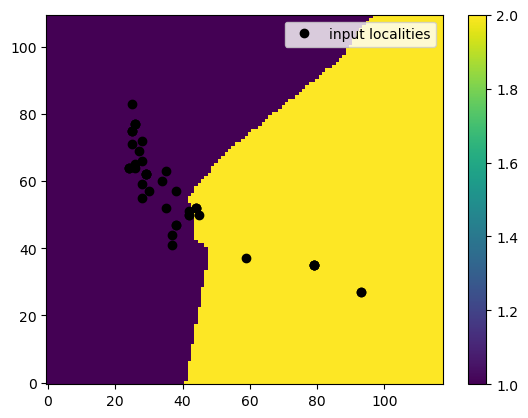

In [418]:
from scipy.interpolate import NearestNDInterpolator
import numpy as np
import matplotlib.pyplot as plt


r_x, r_y = np.indices(r.shape)

interp = NearestNDInterpolator(list(zip(indices_x, indices_y)), localities.spop)
z = interp(r_x, r_y)


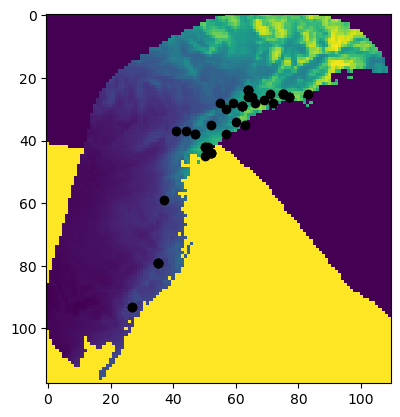

In [421]:
from matplotlib import pyplot


pyplot.imshow(z, cmap='viridis')
pyplot.imshow(r, cmap='viridis')
pyplot.plot(indices_y, indices_x, "ok")


pyplot.show() 

In [423]:
z_masked = ma.masked_array(z, r.mask)


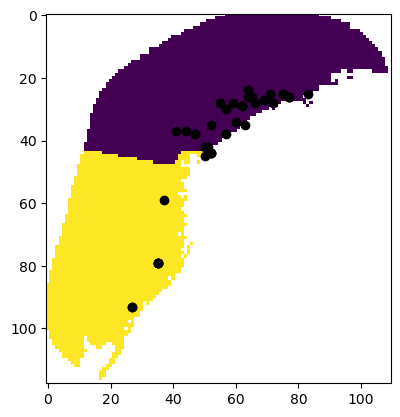

In [426]:
from matplotlib import pyplot

pyplot.imshow(r, cmap='viridis')
pyplot.imshow(z_masked, cmap='viridis')
pyplot.plot(indices_y, indices_x, "ok")


pyplot.show() 

In [693]:
split_landscape_by_admix_pop(raster_path = filepath, coords = coords, admix_id = localities.spop, outfile = "/Users/connorfrench/Downloads/test_kid_rast.tif", mask_rast = False)

Landscape with K assignment categories written to /Users/connorfrench/Downloads/test_kid_rast.tif.


In [466]:
os.path.splitext("~/Downloads/test_kid_rast.tif")

('~/Downloads/test_kid_rast', '.tif')

In [303]:
asize_a1 = [100, 500, 1000]
asize_a2 = [10, 20, 30]

total_list_size = len(asize_a1) * len(asize_a2)
asizes = [[0, 0] for s in range(total_list_size)]

asize_counter = 0
for i in range(len(asize_a1)):
    for j in range(len(asize_a2)):
        asizes[asize_counter][0] = asize_a1[i]
        asizes[asize_counter][1] = asize_a2[j]
        asize_counter += 1

asizes


[[100, 10],
 [100, 20],
 [100, 30],
 [500, 10],
 [500, 20],
 [500, 30],
 [1000, 10],
 [1000, 20],
 [1000, 30]]

In [383]:
n_pops = [2, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99]
gen_div = []
tseqs = []
for i in range(len(n_pops)):
    pop_names = []

    for j in range(n_pops[i]):
        pop_names.append(f"pop_{j}")

    sample_dict = {}

    for n in pop_names:
        sample_dict[n] = 2

    demo = msprime.Demography.stepping_stone_model([100] * n_pops[i], migration_rate=0.01)
    
    #demo.add_population(initial_size=2e6, name="ANC")

    #demo.add_population_split(22000, derived = pop_names, ancestral="ANC")

    ts_simple = msprime.sim_ancestry(samples = sample_dict, sequence_length=1e6, demography=demo, recombination_rate=1e-8)

    mu_simple = msprime.sim_mutations(ts_simple, rate = 1e-9)


    div = mu_simple.diversity()

    gen_div.append(div)

    tseqs.append(mu_simple)


array([], dtype=int32)

In [387]:
est_ne = []
for i in gen_div:
    est_ne.append(i / 4 / 1e-9)

est_ne

[214.28571428571428,
 684.2948717948717,
 1825.0791139240514,
 6768.452380952375,
 8131.191037735845,
 9805.678391959798,
 16197.724895397476,
 15083.250128008192,
 18895.116575235123,
 24759.215413184742,
 29974.15931466562]

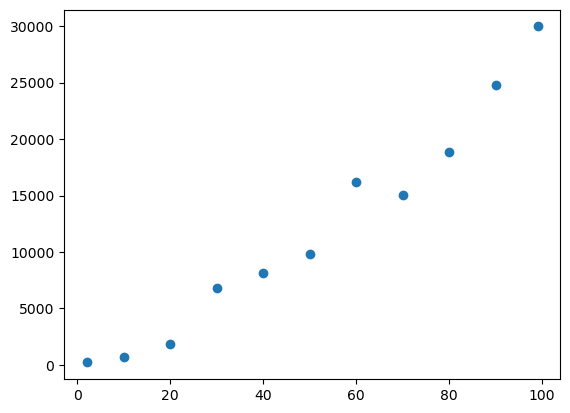

In [385]:
from matplotlib import pyplot

pyplot.scatter(n_pops, est_ne)

In [433]:
def coal_time_1dss(
        n_e = 100, 
        n_d = 100,
        k = 0.01,
        m = 1e-8):
    
    ct = 2 * n_e * n_d + (n_d - k) * (k / m)

    return(ct)

coal_times = []

for p in n_pops:
    coal_times.append(coal_time_1dss(n_d = p))

coal_times


[1990400.0,
 9992000.0,
 19994000.0,
 29996000.0,
 39998000.0,
 50000000.0,
 60002000.0,
 70004000.0,
 80006000.0,
 90008000.0,
 99009800.0]

ValueError: x and y must be the same size

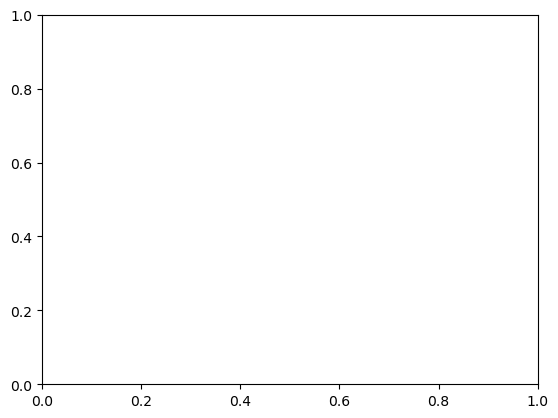

In [390]:
pyplot.scatter(n_pops, coal_times)

In [382]:
tseqs[10].diversity(sample_sets=[6,7])

6e-06

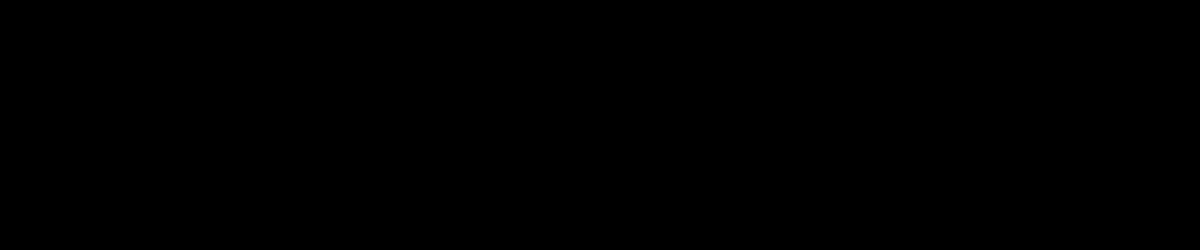

In [430]:

wide_fmt = (1200, 250)
# Create a stylesheet that shrinks labels and rotates leaf labels, to avoid overlap
node_label_style = (
    ".node > .lab {font-size: 80%}"
    ".leaf > .lab {text-anchor: start; transform: rotate(90deg) translate(6px)}"
)
tseqs[7].first().draw_svg(
    size=wide_fmt,
    time_scale="log_time",
    y_gridlines=True,
    y_axis=True,
    y_ticks=[1, 10, 100, 1000, 10000, 100000, 1e6],
    style=node_label_style,
)

In [429]:
it = 7

div_list = []
for i in range(tseqs[it].num_populations):
    div = tseqs[it].diversity(tseqs[it].get_samples(i))
    div_list.append(div)

div_list

[2.9000000000000007e-05,
 1.7999999999999997e-05,
 2.4333333333333343e-05,
 1.85e-05,
 2.25e-05,
 2.05e-05,
 1.3166666666666662e-05,
 8e-06,
 1.85e-05,
 1.4333333333333329e-05,
 1.6e-05,
 3.666666666666668e-05,
 3.3500000000000015e-05,
 1.4666666666666666e-05,
 2.6833333333333336e-05,
 2.8333333333333332e-05,
 2.8166666666666673e-05,
 2.5333333333333334e-05,
 2.3166666666666673e-05,
 2.2333333333333332e-05,
 3.183333333333335e-05,
 2.6333333333333344e-05,
 0.0,
 2.2166666666666672e-05,
 3.433333333333334e-05,
 9.166666666666668e-06,
 4.566666666666667e-05,
 3.65e-05,
 1.583333333333333e-05,
 1.0333333333333332e-05,
 2.7666666666666667e-05,
 1.5e-05,
 2e-05,
 2.2999999999999997e-05,
 1.8666666666666665e-05,
 1.8999999999999998e-05,
 3.45e-05,
 2.6333333333333348e-05,
 7.666666666666667e-06,
 0.0,
 0.0,
 2.5666666666666683e-05,
 0.0,
 1.5166666666666668e-05,
 2.9e-05,
 3.250000000000002e-05,
 1.35e-05,
 0.0,
 7.166666666666666e-06,
 7e-06,
 3.1833333333333346e-05,
 2.650000000000001e-05,

10

In [412]:
tseqs[0].num_populations

2